### Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import RFE


### Understanding the data

In [2]:
# Load the dataset
df = pd.read_csv('UCEC_TCGA_Clinical_data.csv')
df.head()

,Diagnosis Age,Cancer Type Detailed,JCCC Stage,History Diabetes,Ethnicity,Fraction Genome Altered,Neoplasm Histologic Grade,Patient Height,History colorectal cancer,History hormol contraceptives use,...,Menopause Status,Mutation Count,Peritoneal washing,Pregncies full term count,Race Category,Surgical Margin Resection Status,Surgical approach at diagnosis,TMB (nonsynonymous),Tumor invasion percent,Patient Weight
0,59.0,EC,Stage III,NO,NOT HISPANIC OR LATINO,0.3311,G2,157.0,NO,Never Used,...,Post,NaN,[Not Evaluated],2,BLACK OR AFRICAN AMERICAN,R0,Minimally Invasive,NaN,280.0,71.0
1,54.0,UEC,Stage I,NO,NOT HISPANIC OR LATINO,0.0341,G1,162.0,NO,Never Used,...,Post,NaN,negative,1,BLACK OR AFRICAN AMERICAN,R0,open,NaN,NaN,76.0
2,69.0,UEC,Stage IA,NO,NOT HISPANIC OR LATINO,0.6903,G2,158.0,NO,NaN,...,Post,NaN,NaN,2,BLACK OR AFRICAN AMERICAN,NaN,Minimally Invasive,NaN,NaN,98.0
3,51.0,UEC,Stage IIIA,YES,NOT HISPANIC OR LATINO,0.0581,G2,162.0,NO,NaN,...,NaN,NaN,NaN,0,BLACK OR AFRICAN AMERICAN,R0,open,NaN,50.0,86.0
4,67.0,USC/UPSC,Stage IA,NaN,NOT HISPANIC OR LATINO,0.0001,G3,168.0,NaN,NaN,...,Post,NaN,NaN,NaN,WHITE,R0,open,NaN,10.0,59.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549 entries, 0 to 548
Data columns (total 24 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Diagnosis Age                       546 non-null    float64
 1   Cancer Type Detailed                549 non-null    object 
 2   JCCC Stage                          549 non-null    object 
 3   History Diabetes                    46 non-null     object 
 4   Ethnicity                           393 non-null    object 
 5   Fraction Genome Altered             540 non-null    float64
 6   Neoplasm Histologic Grade           549 non-null    object 
 7   Patient Height                      520 non-null    float64
 8   History colorectal cancer           52 non-null     object 
 9   History hormol contraceptives use   28 non-null     object 
 10  History menopausal hormone therapy  29 non-null     object 
 11  Prior Cancer Diagnosis Occurence    549 non-n

In [4]:
print(f"Shape of the dataset: {df.shape}")
print(f"Number of samples in the dataset: {df.shape[0]}")
print(f"Number of features in the dataset: {df.shape[1] - 1}")

Shape of the dataset: (549, 24)
Number of samples in the dataset: 549
Number of features in the dataset: 23


In [5]:
# Check for missing values
print([df.isnull().sum()] if df.isnull().sum().sum() > 0 else "No missing values in the dataset")

[Diagnosis Age                           3
Cancer Type Detailed                    0
JCCC Stage                              0
History Diabetes                      503
Ethnicity                             156
Fraction Genome Altered                 9
Neoplasm Histologic Grade               0
Patient Height                         29
History colorectal cancer             497
History hormol contraceptives use     521
History menopausal hormone therapy    520
Prior Cancer Diagnosis Occurence        0
History tamoxifen use                 504
Hypertension diagnosis                503
Menopause Status                       31
Mutation Count                        301
Peritoneal washing                    137
Pregncies full term count             503
Race Category                          32
Surgical Margin Resection Status       93
Surgical approach at diagnosis         24
TMB (nonsynonymous)                   301
Tumor invasion percent                 74
Patient Weight                   

### Data Preprocessing

In [6]:
y = df['Cancer Type Detailed']
X = df.drop(columns=['Cancer Type Detailed'])

In [7]:
numeric_cols = X.select_dtypes(include=['int64','float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

In [8]:
print(f"Numerical features to impute: {len(numeric_cols)}")
print(f"Categorical features to impute: {len(categorical_cols)}")

Numerical features to impute: 7
Categorical features to impute: 16


In [9]:
# Imputing numeric variables with median
for col in numeric_cols:
    if X[col].isnull().sum() > 0:
        median_val = X[col].median()
        X[col] = X[col].fillna(median_val)
        print(f"Imputed {col} with Median: {median_val}")

# Imputing categorical variables with mode
for col in categorical_cols:
    if X[col].isnull().sum() > 0:
        mode_val = X[col].mode()[0]
        X[col] = X[col].fillna(mode_val)
        print(f"Imputed {col} with Mode: {mode_val}")

Imputed Diagnosis Age with Median: 64.0
Imputed Fraction Genome Altered with Median: 0.08065
Imputed Patient Height with Median: 161.0
Imputed Mutation Count with Median: 56.5
Imputed TMB (nonsynonymous) with Median: 1.866666667
Imputed Tumor invasion percent with Median: 40.0
Imputed Patient Weight with Median: 84.0
Imputed History Diabetes with Mode: NO
Imputed Ethnicity with Mode: NOT HISPANIC OR LATINO
Imputed History colorectal cancer with Mode: NO
Imputed History hormol contraceptives use with Mode: Never Used
Imputed History menopausal hormone therapy with Mode: No
Imputed History tamoxifen use with Mode: Never Used
Imputed Hypertension diagnosis with Mode: YES
Imputed Menopause Status with Mode: Post
Imputed Peritoneal washing with Mode: negative
Imputed Pregncies full term count with Mode: 4+
Imputed Race Category with Mode: WHITE
Imputed Surgical Margin Resection Status with Mode: R0
Imputed Surgical approach at diagnosis with Mode: open


In [10]:
print([X.isnull().sum()] if X.isnull().sum().sum() > 0 else "No missing values in the dataset")

No missing values in the dataset


### Exploratory data analysis

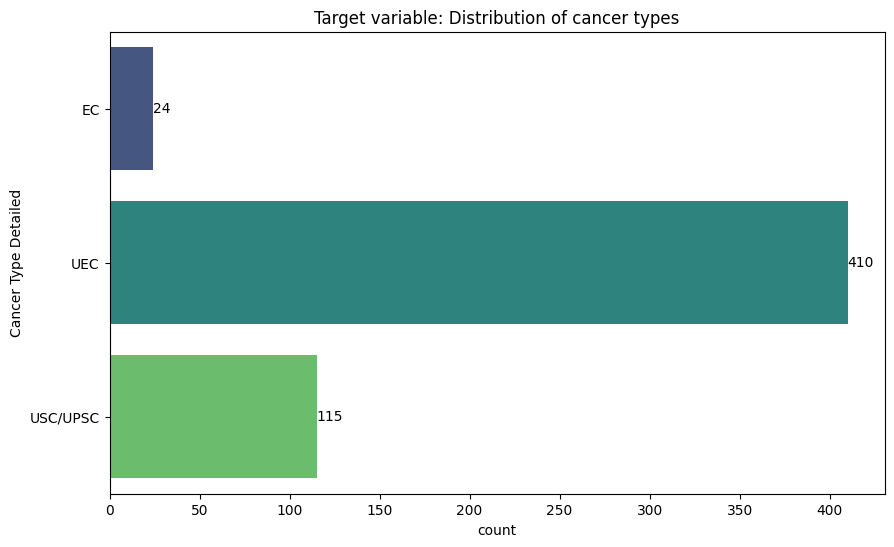

Class distribution:
UEC: 410 (74.68%)
USC/UPSC: 115 (20.95%)
EC: 24 (4.37%)


In [11]:
plt.figure(figsize=(10,6))
ax = sns.countplot(y=y, hue=y, palette='viridis')
plt.title('Target variable: Distribution of cancer types')

for bar in ax.containers:
    ax.bar_label(bar)

labels = [label.get_text() for label in ax.get_yticklabels()]

ax.set_yticks(ax.get_yticks())
ax.set_yticklabels(labels)
plt.show()

print("Class distribution:")
value_counts = y.value_counts()
value_percentages = y.value_counts(normalize=True) * 100

for c_type in value_counts.index:
    print(f"{c_type}: {value_counts[c_type]} ({value_percentages[c_type]:.2f}%)")

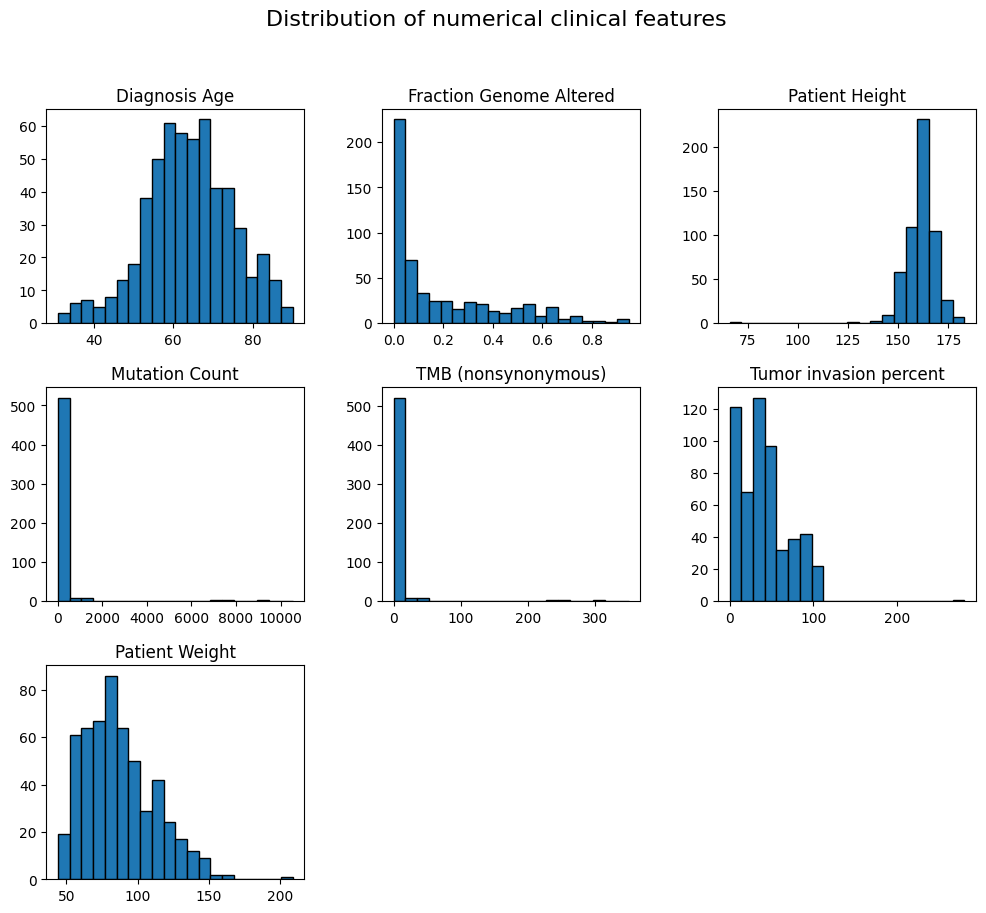

In [12]:
X[numeric_cols].hist(figsize=(12,10), bins=20, edgecolor='black', grid=False)
plt.suptitle('Distribution of numerical clinical features', fontsize=16)
plt.show()

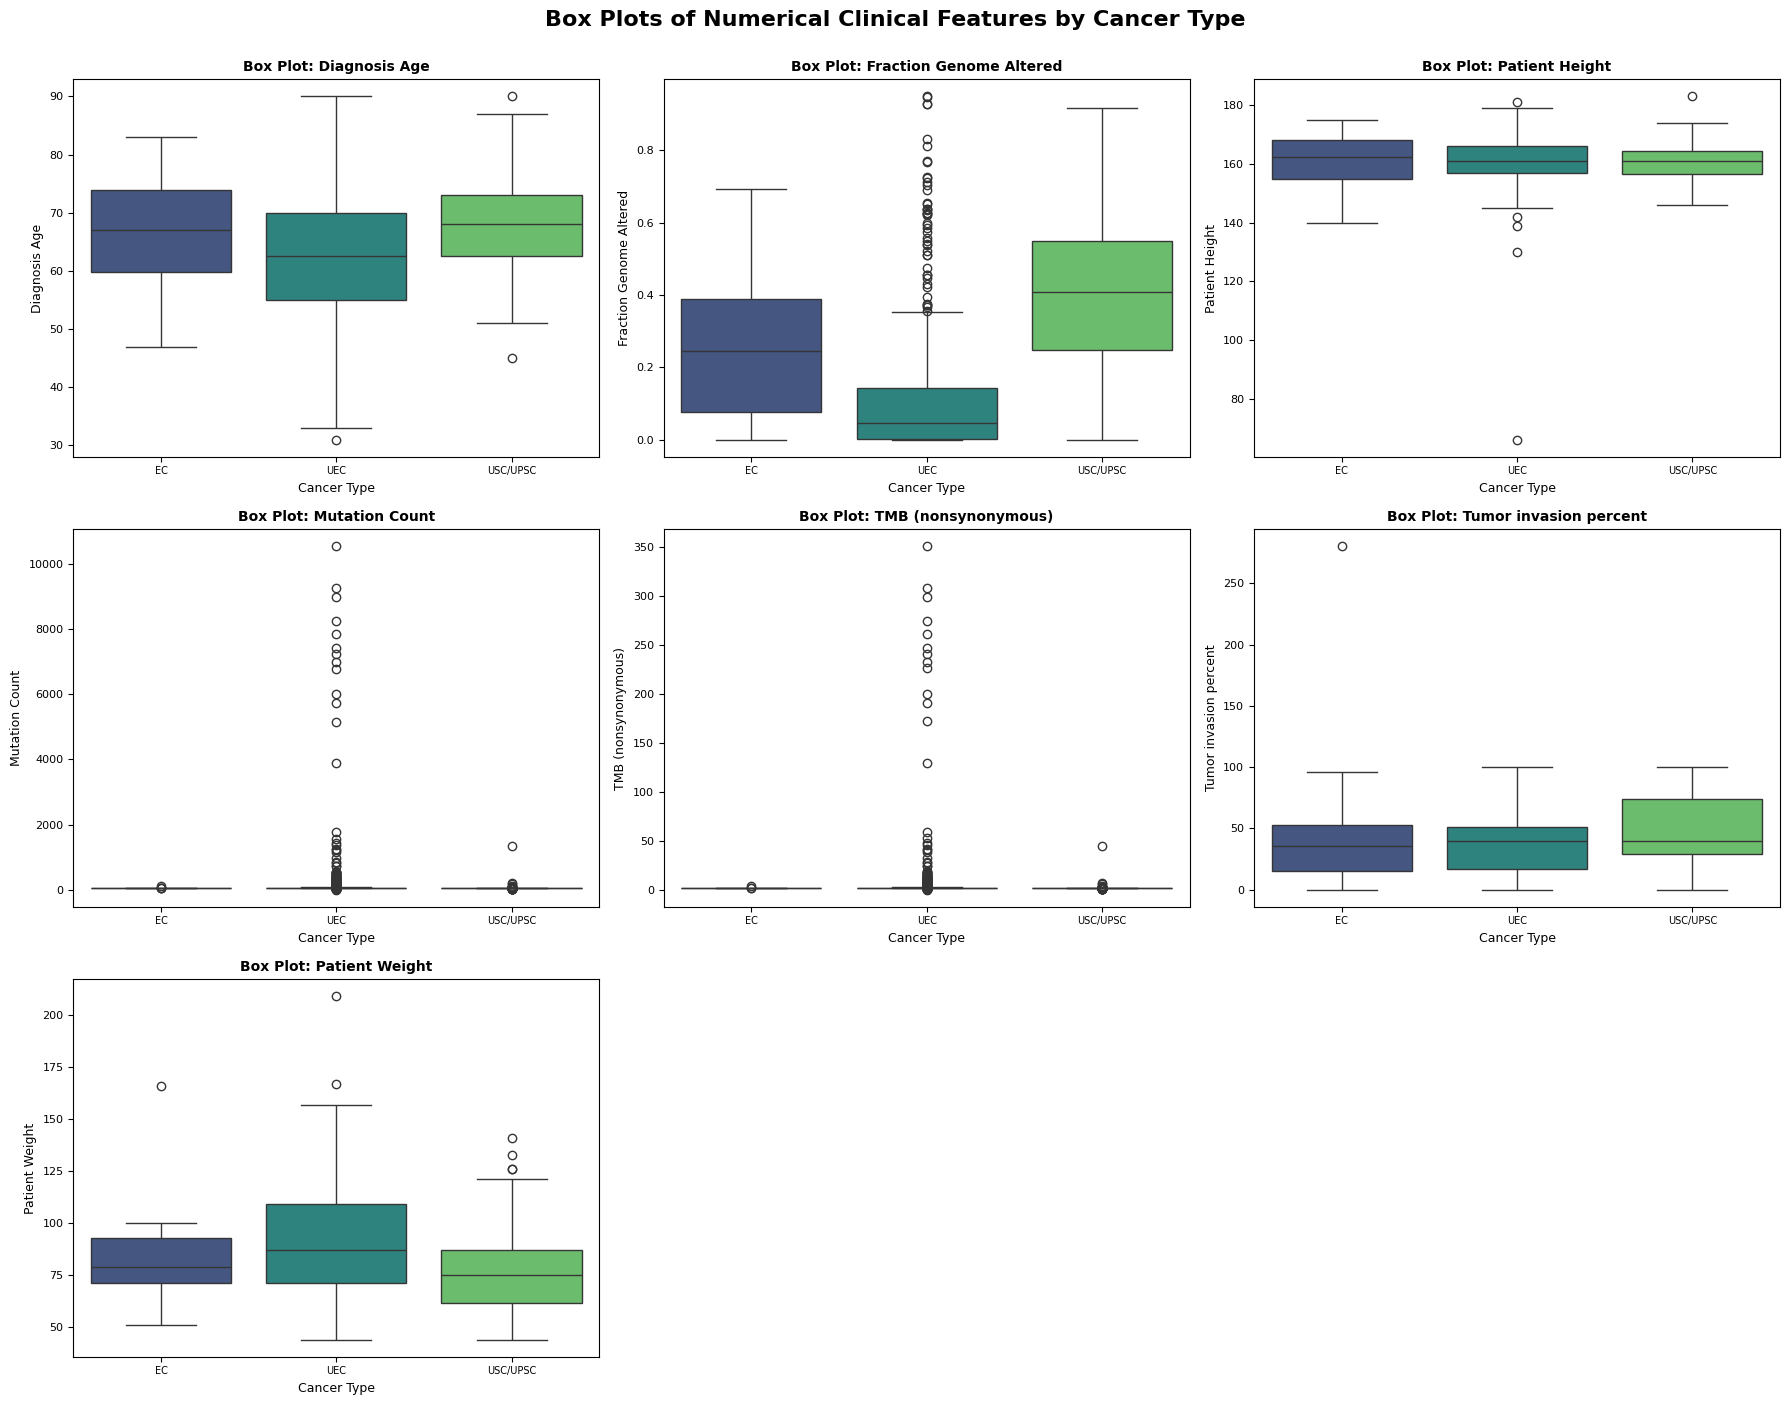

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(x=y, y=X[col], hue=y, ax=axes[idx], palette='viridis')
    axes[idx].set_title(f'Box Plot: {col}', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Cancer Type', fontsize=9)
    axes[idx].set_ylabel(col, fontsize=9)
    
    axes[idx].set_xticks(axes[idx].get_xticks())
    axes[idx].set_xticklabels(labels, rotation=0, ha='center', fontsize=7)
    axes[idx].tick_params(axis='y', labelsize=8)

# Remove extra subplots if any
for i in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle('Box Plots of Numerical Clinical Features by Cancer Type', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

Generating Count Plots for Categorical Features


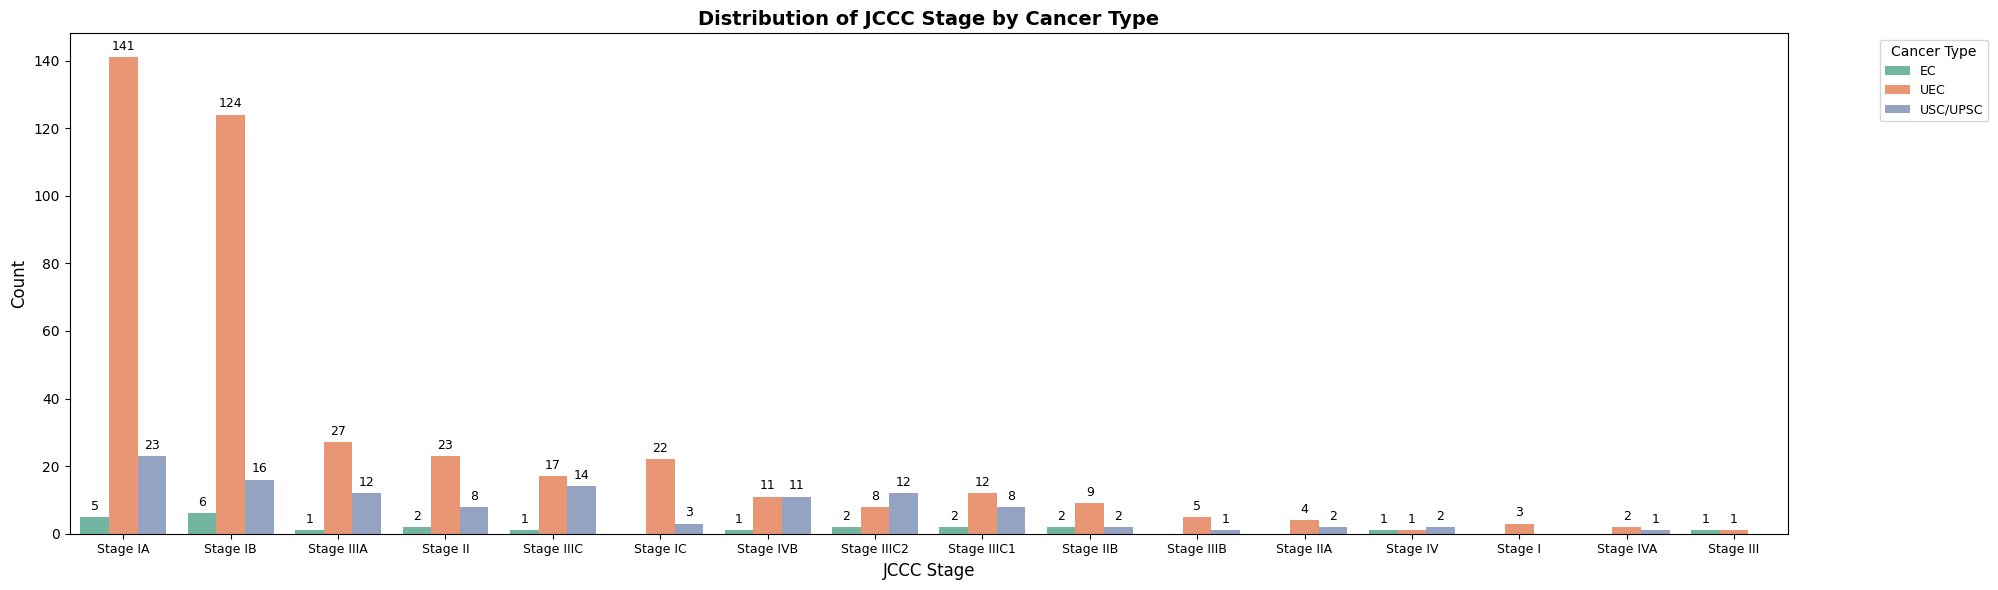

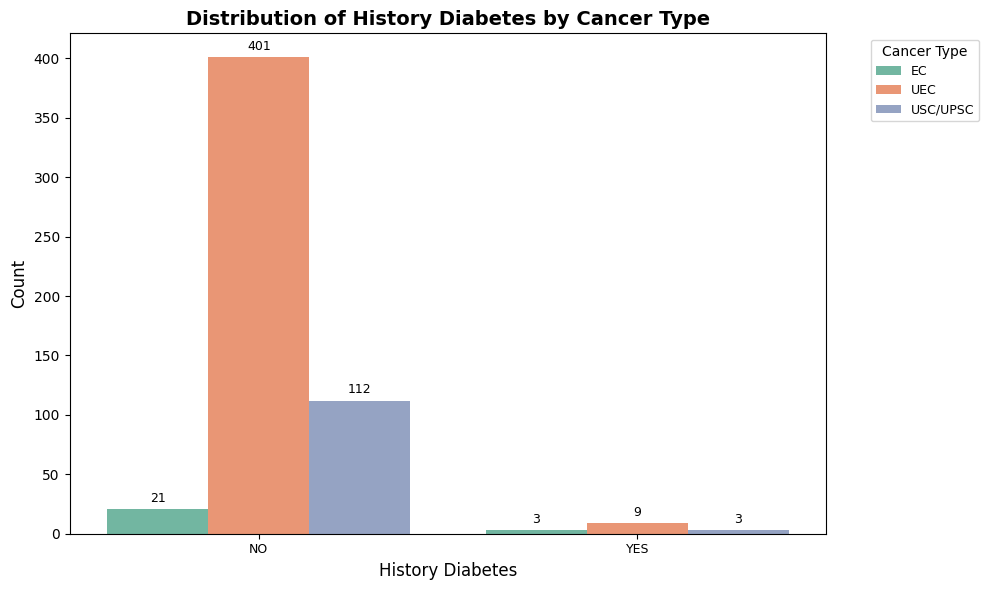

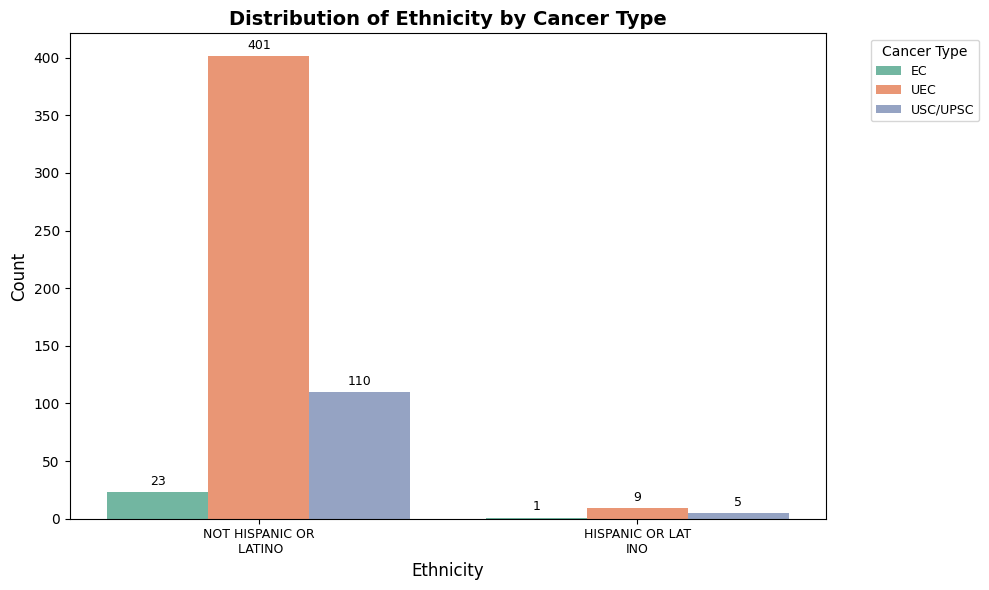

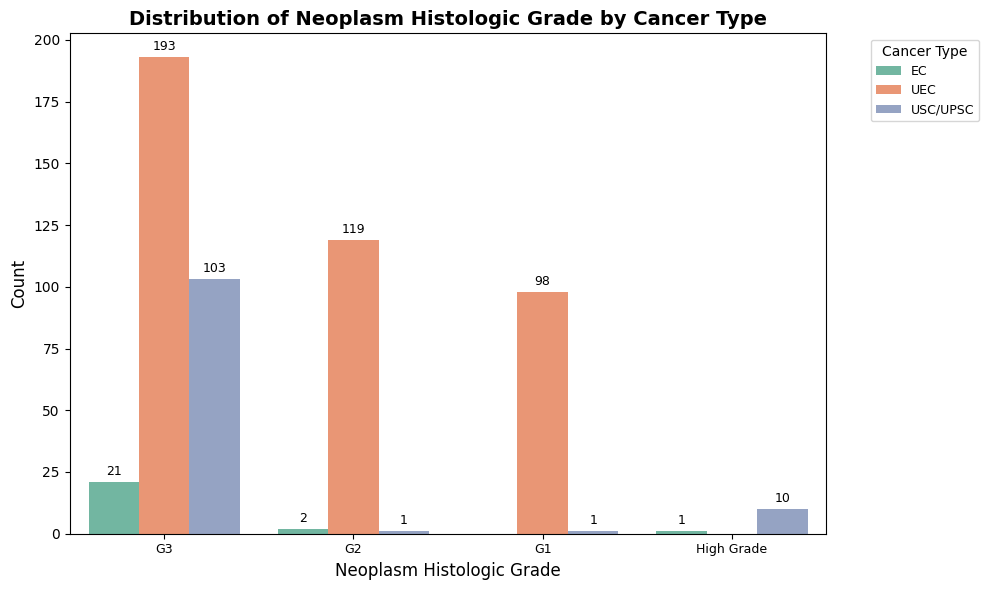

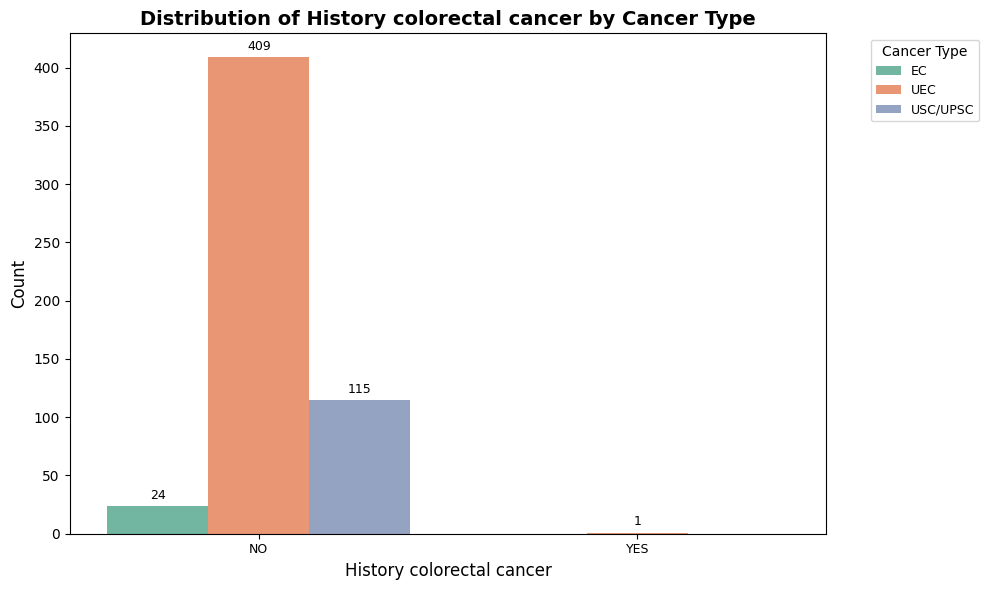

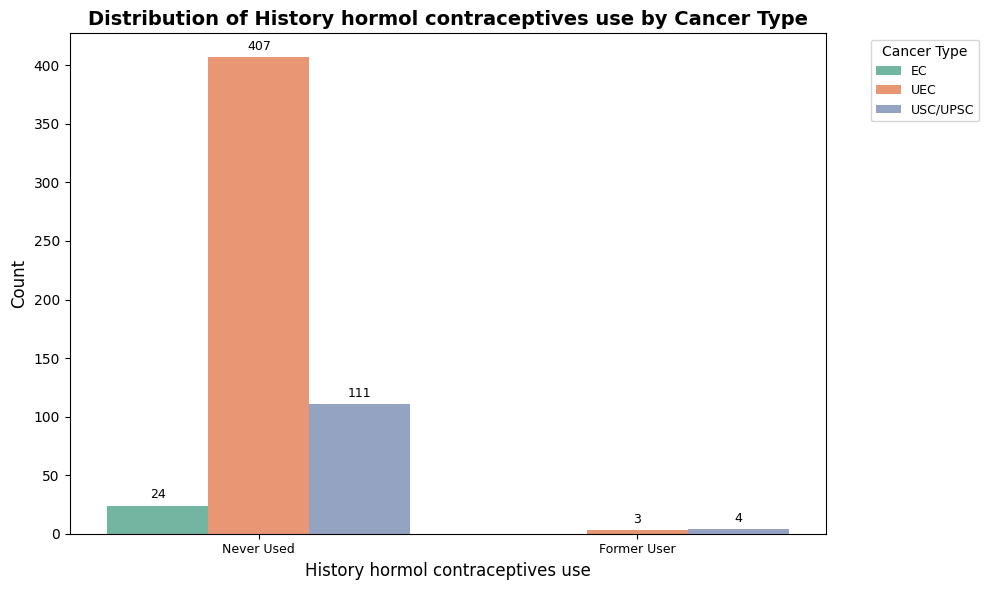

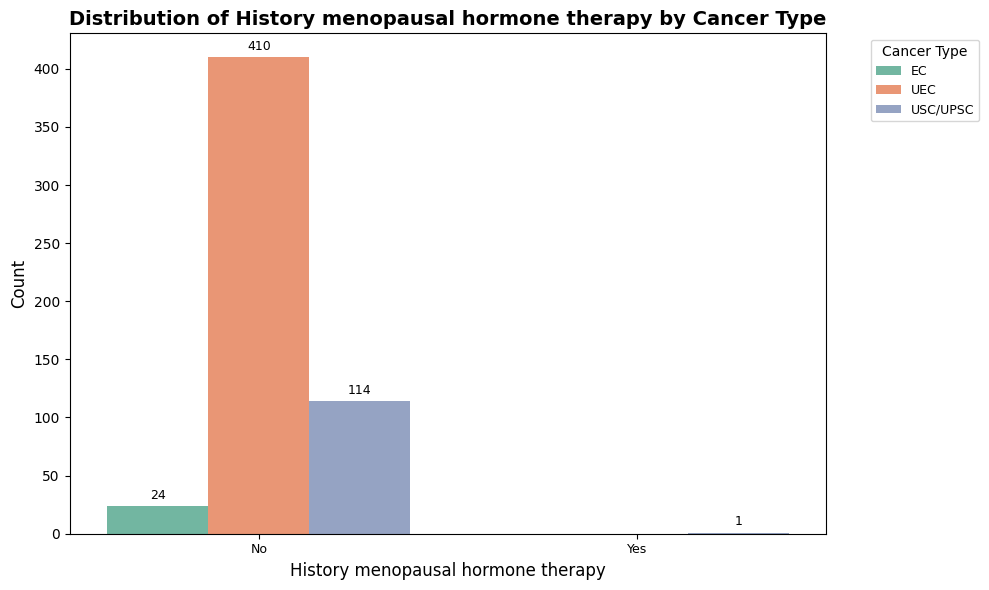

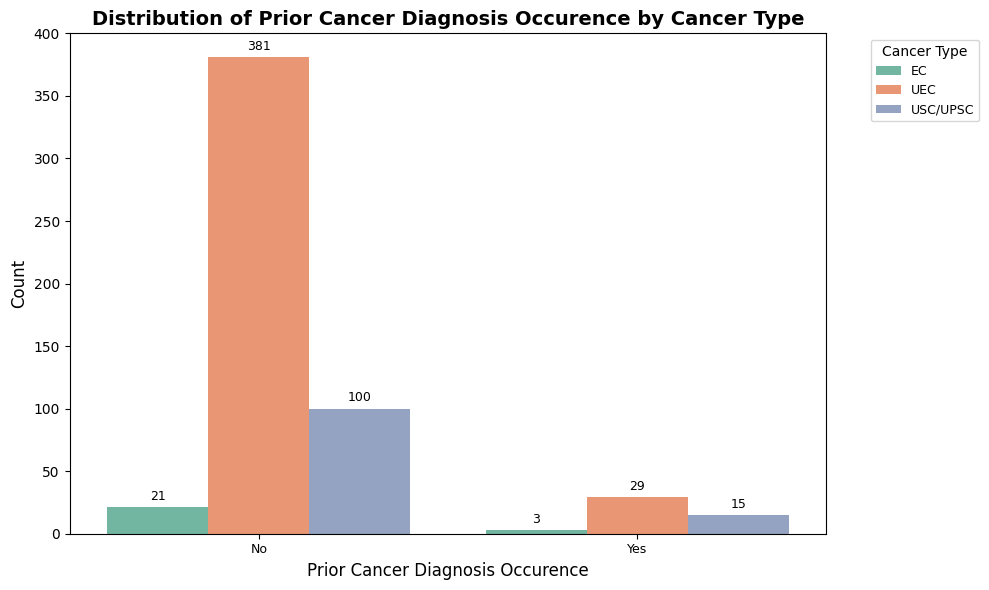

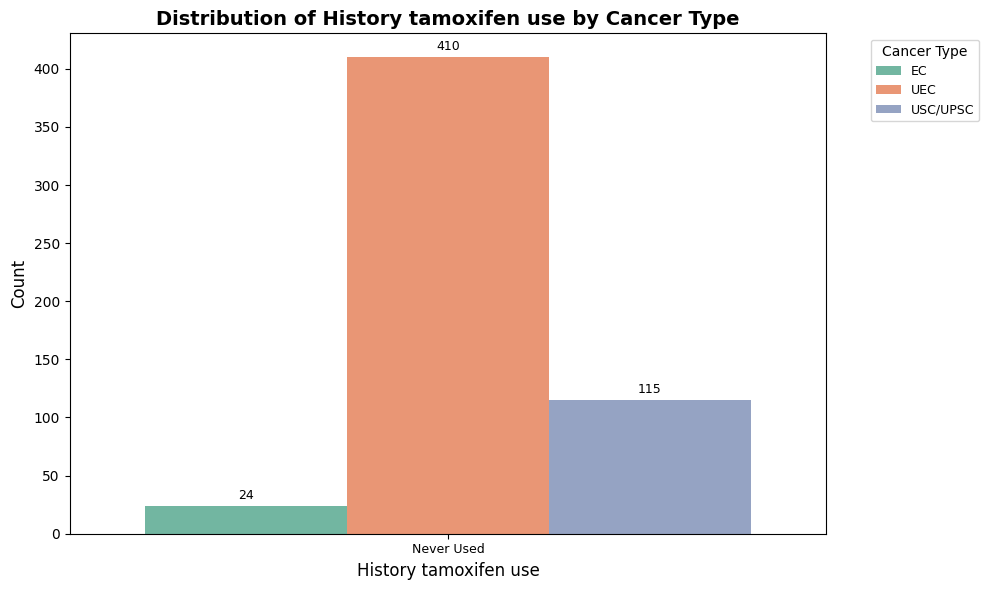

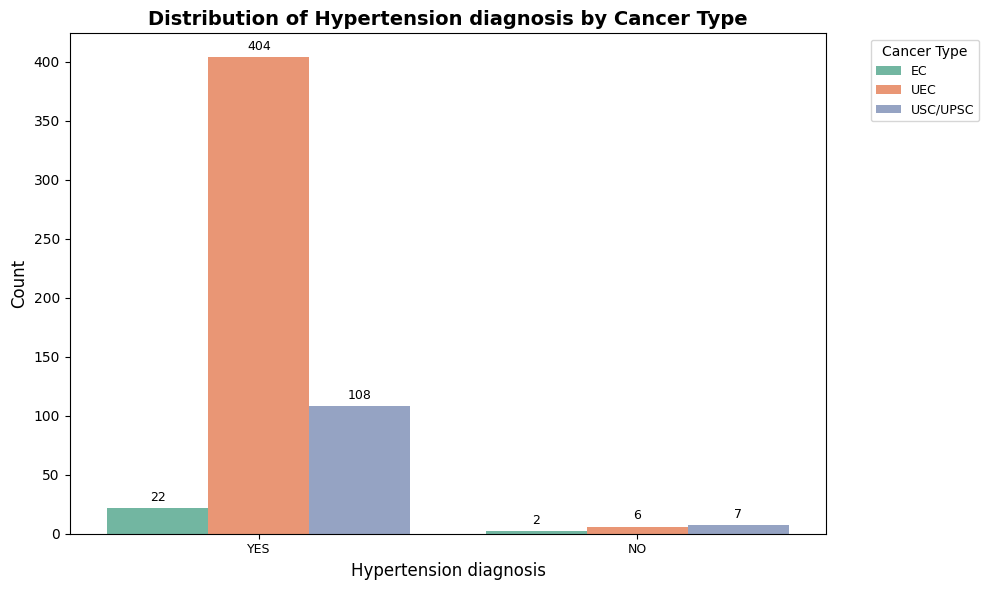

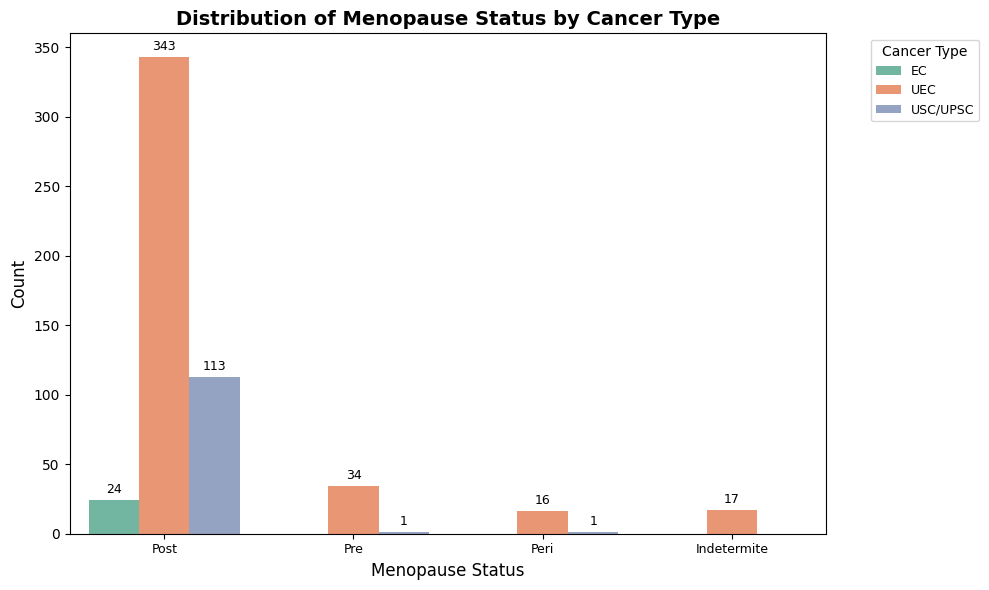

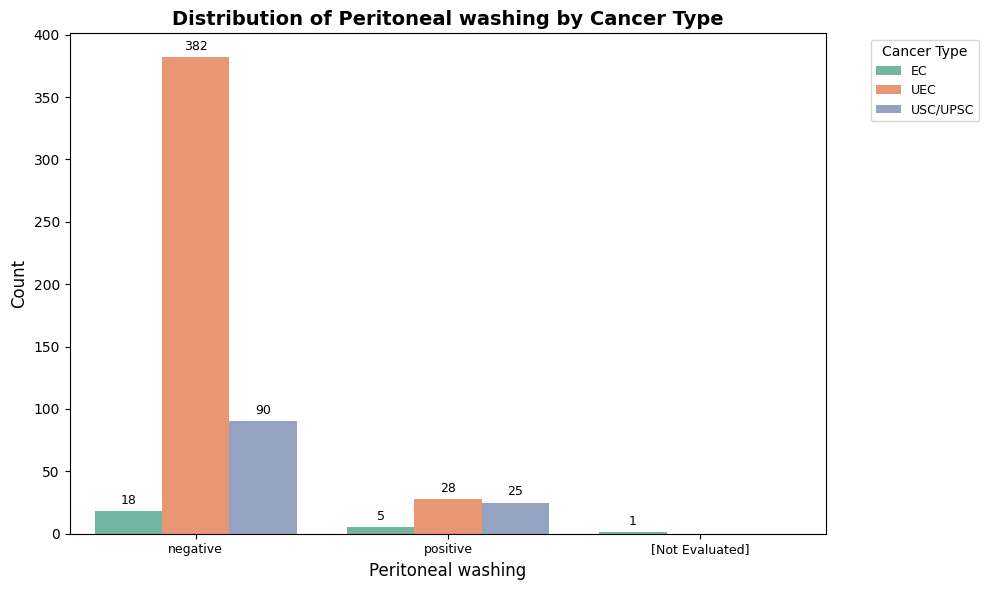

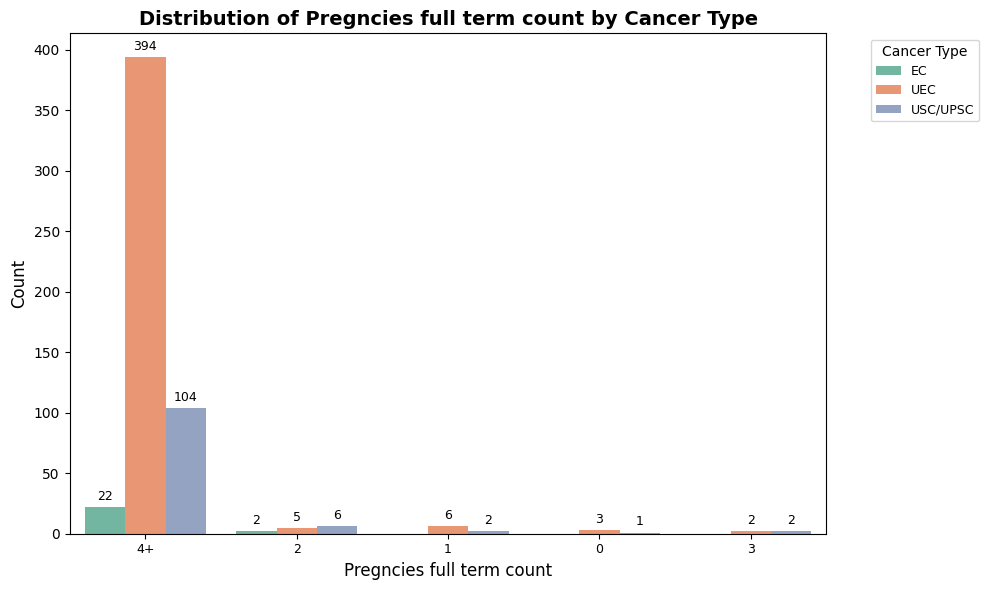

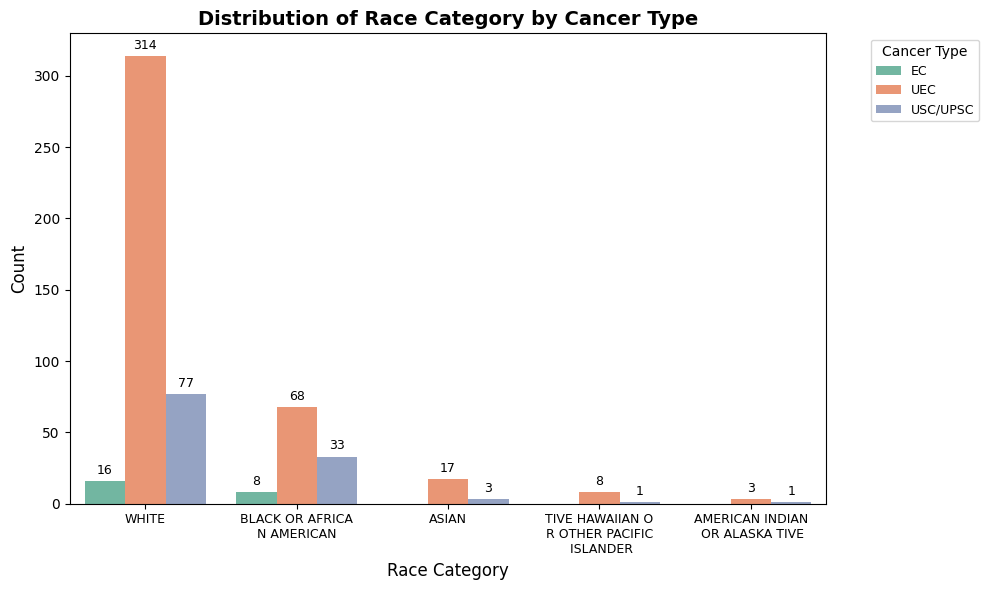

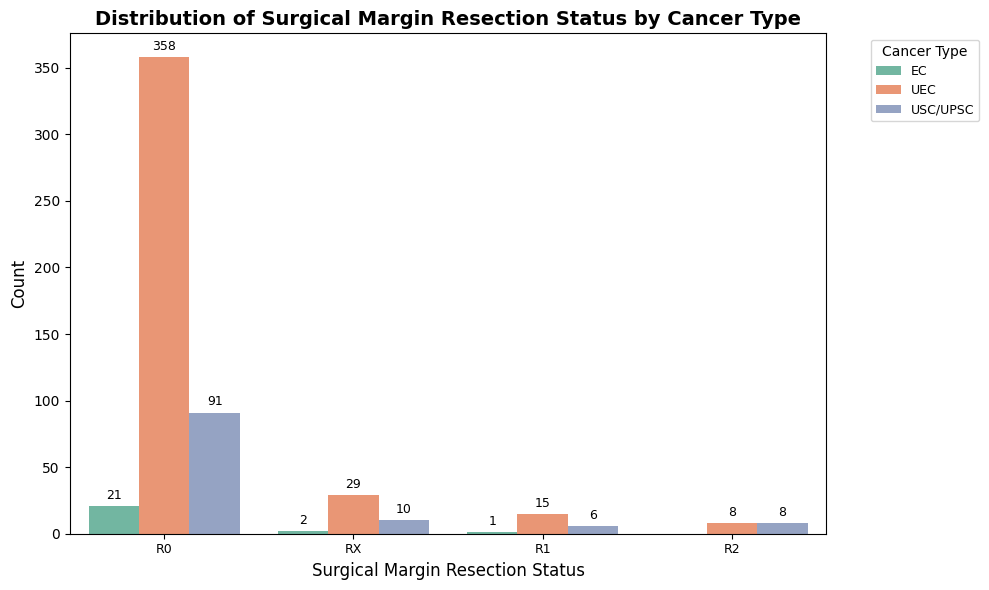

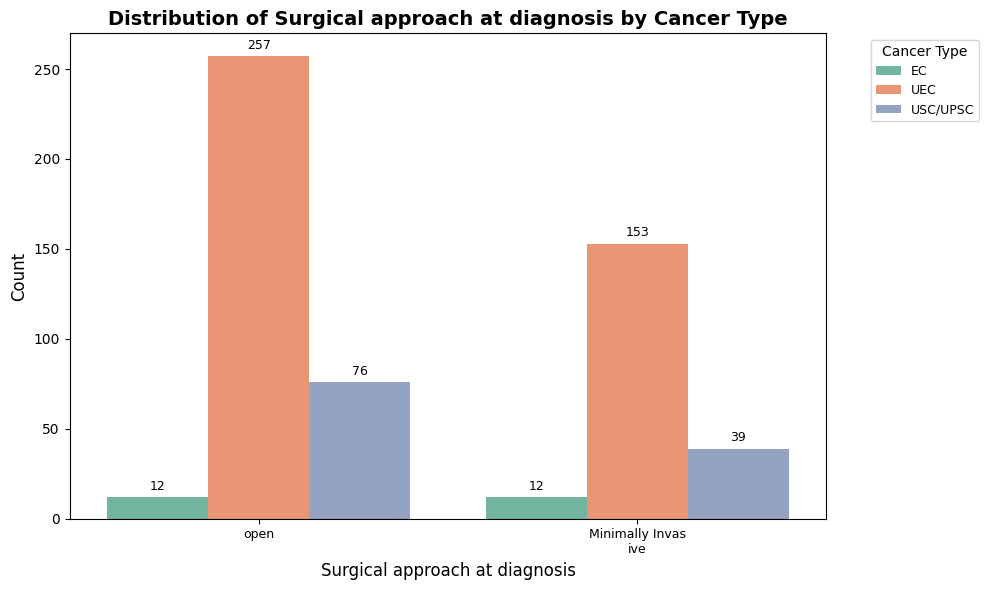

In [14]:
print("Generating Count Plots for Categorical Features")

for col in categorical_cols:
    
    n_categories = X[col].nunique()
    fig_width = max(10, min(n_categories * 1.5, 20))
    
    plt.figure(figsize=(fig_width, 6))
    
    # Create countplot 
    ax = sns.countplot(
        data=X, 
        x=col, 
        hue=y,
        palette='Set2',
        order=X[col].value_counts().index
    )
    
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=3, fontsize=9)
    
    plt.title(f'Distribution of {col} by Cancer Type', fontsize=14, fontweight='bold')
    plt.ylabel('Count', fontsize=12)
    plt.xlabel(col, fontsize=12)
    
    labels = [label.get_text() for label in ax.get_xticklabels()]
    wrapped_labels = ['\n'.join([labels[i][j:j+15] for j in range(0, len(labels[i]), 15)]) 
                      for i in range(len(labels))]
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(wrapped_labels, fontsize=9)
    
    plt.legend(title='Cancer Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.show()

### Data Transformations

In [15]:
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

labelencoder = LabelEncoder()
y_encoded = labelencoder.fit_transform(y)

print("Shape of features after One-Hot encoding:", X_encoded.shape)
print("Target class mapping:", dict(zip(labelencoder.classes_, labelencoder.transform(labelencoder.classes_))))

Shape of features after One-Hot encoding: (549, 49)
Target class mapping: {'EC': np.int64(0), 'UEC': np.int64(1), 'USC/UPSC': np.int64(2)}


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
print(f"Class distribution in training set: {np.bincount(y_train)}")

Class distribution in training set: [ 17 287  80]


In [20]:
smote = SMOTE(random_state=42)
X_train_smote , y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f"Class distribution in training set after resampling: {np.bincount(y_train_smote)}")

Class distribution in training set after resampling: [287 287 287]


### Baseline models

In [21]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Naive Bayes': GaussianNB(),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='mlogloss', random_state=42)
}

print(f"Initialized {len(models)} baseline models")

Initialized 6 baseline models


In [22]:
baseline_results = {}

print("Training Baseline Models")

for name, model in models.items():
    print(f"\nTraining {name}")
    
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    
    # Calculate metrics 
    accuracy = accuracy_score(y_test, y_pred)
    precision_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall_weighted = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    
    baseline_results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision_weighted,
        'recall': recall_weighted,
        'f1_score': f1_weighted,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'predictions': y_pred
    }
    
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision (macro): {precision_macro:.4f}")
    print(f"  Recall (macro):    {recall_macro:.4f}")
    print(f"  F1-Score (macro):  {f1_macro:.4f}")

print("Baseline training complete!")

Training Baseline Models

Training Logistic Regression
  Accuracy: 0.7939
  Precision (macro): 0.5531
  Recall (macro):    0.5566
  F1-Score (macro):  0.5546

Training Decision Tree
  Accuracy: 0.7697
  Precision (macro): 0.5620
  Recall (macro):    0.5362
  F1-Score (macro):  0.5474

Training Random Forest
  Accuracy: 0.8000
  Precision (macro): 0.4822
  Recall (macro):    0.4736
  F1-Score (macro):  0.4748

Training Naive Bayes
  Accuracy: 0.3879
  Precision (macro): 0.5200
  Recall (macro):    0.5287
  F1-Score (macro):  0.3227

Training Neural Network
  Accuracy: 0.7697
  Precision (macro): 0.4804
  Recall (macro):    0.4804
  F1-Score (macro):  0.4804

Training XGBoost
  Accuracy: 0.7758
  Precision (macro): 0.4626
  Recall (macro):    0.4900
  F1-Score (macro):  0.4755
Baseline training complete!


In [23]:
print("Summary of Baseline Models Performance:")

baseline_summary = pd.DataFrame([{
    'Model': name,
    'Test Accuracy': results['accuracy'],
    'Test F1 (Macro)': results['f1_macro'],
    'Test F1 (Weighted)': results['f1_score']
} for name, results in baseline_results.items()])

baseline_summary

Summary of Baseline Models Performance:


,Model,Test Accuracy,Test F1 (Macro),Test F1 (Weighted)
0,Logistic Regression,0.793939,0.554649,0.796182
1,Decision Tree,0.769697,0.547416,0.761749
2,Random Forest,0.800000,0.474766,0.773919
3,Naive Bayes,0.387879,0.322661,0.490471
4,Neural Network,0.769697,0.480449,0.769697
5,XGBoost,0.775758,0.475466,0.764647


### SMOTE models

In [24]:
models_smote = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Naive Bayes': GaussianNB(),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='mlogloss', random_state=42)
}

smote_results = {}

print("Training Models with SMOTE")

for name, model in models_smote.items():
    print(f"Training {name} with SMOTE")
    
    model.fit(X_train_smote, y_train_smote)
    
    y_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall_weighted = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    
    smote_results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision_weighted,
        'recall': recall_weighted,
        'f1_score': f1_weighted,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'predictions': y_pred
    }
    
    print(f"  Accuracy:          {accuracy:.4f}")
    print(f"  Precision (macro): {precision_macro:.4f}")
    print(f"  Recall (macro):    {recall_macro:.4f}")
    print(f"  F1-Score (macro):  {f1_macro:.4f}")

print("SMOTE training complete!")

Training Models with SMOTE
Training Logistic Regression with SMOTE
  Accuracy:          0.7091
  Precision (macro): 0.5531
  Recall (macro):    0.6153
  F1-Score (macro):  0.5460
Training Decision Tree with SMOTE
  Accuracy:          0.6970
  Precision (macro): 0.4774
  Recall (macro):    0.5037
  F1-Score (macro):  0.4876
Training Random Forest with SMOTE
  Accuracy:          0.8242
  Precision (macro): 0.5099
  Recall (macro):    0.5593
  F1-Score (macro):  0.5309
Training Naive Bayes with SMOTE
  Accuracy:          0.3818
  Precision (macro): 0.4962
  Recall (macro):    0.4811
  F1-Score (macro):  0.3142
Training Neural Network with SMOTE
  Accuracy:          0.7636
  Precision (macro): 0.4893
  Recall (macro):    0.4777
  F1-Score (macro):  0.4833
Training XGBoost with SMOTE
  Accuracy:          0.8000
  Precision (macro): 0.6040
  Recall (macro):    0.5730
  F1-Score (macro):  0.5739
SMOTE training complete!


In [25]:
print("Summary of SMOTE Models Performance:")

smote_summary = pd.DataFrame([{
    'Model': name,
    'Test Accuracy': results['accuracy'],
    'Test F1 (Macro)': results['f1_macro'],
    'Test F1 (Weighted)': results['f1_score']
} for name, results in smote_results.items()])

smote_summary

Summary of SMOTE Models Performance:


,Model,Test Accuracy,Test F1 (Macro),Test F1 (Weighted)
0,Logistic Regression,0.709091,0.545959,0.756274
1,Decision Tree,0.696970,0.487640,0.705943
2,Random Forest,0.824242,0.530854,0.813849
3,Naive Bayes,0.381818,0.314213,0.486178
4,Neural Network,0.763636,0.483341,0.767201
5,XGBoost,0.800000,0.573926,0.796581


### Evaluating the baseline and SMOTE models

In [26]:
comparison_data = []

for name in models.keys():
    comparison_data.append({
        'Model': name,
        'Method': 'Baseline',
        'Accuracy': baseline_results[name]['accuracy'],
        'Precision (Macro)': baseline_results[name]['precision_macro'],
        'Recall (Macro)': baseline_results[name]['recall_macro'],
        'F1-Score (Macro)': baseline_results[name]['f1_macro']
    })
    comparison_data.append({
        'Model': name,
        'Method': 'SMOTE',
        'Accuracy': smote_results[name]['accuracy'],
        'Precision (Macro)': smote_results[name]['precision_macro'],
        'Recall (Macro)': smote_results[name]['recall_macro'],
        'F1-Score (Macro)': smote_results[name]['f1_macro']
    })

comparison_df = pd.DataFrame(comparison_data)

print("Model Performance Comparison: Baseline vs SMOTE")
comparison_df

Model Performance Comparison: Baseline vs SMOTE


,Model,Method,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
0,Logistic Regression,Baseline,0.793939,0.553064,0.556640,0.554649
1,Logistic Regression,SMOTE,0.709091,0.553138,0.615331,0.545959
2,Decision Tree,Baseline,0.769697,0.562016,0.536198,0.547416
3,Decision Tree,SMOTE,0.696970,0.477448,0.503678,0.487640
4,Random Forest,Baseline,0.800000,0.482186,0.473558,0.474766
5,Random Forest,SMOTE,0.824242,0.509928,0.559350,0.530854
6,Naive Bayes,Baseline,0.387879,0.519966,0.528688,0.322661
7,Naive Bayes,SMOTE,0.381818,0.496166,0.481069,0.314213
8,Neural Network,Baseline,0.769697,0.480449,0.480449,0.480449
9,Neural Network,SMOTE,0.763636,0.489283,0.477739,0.483341


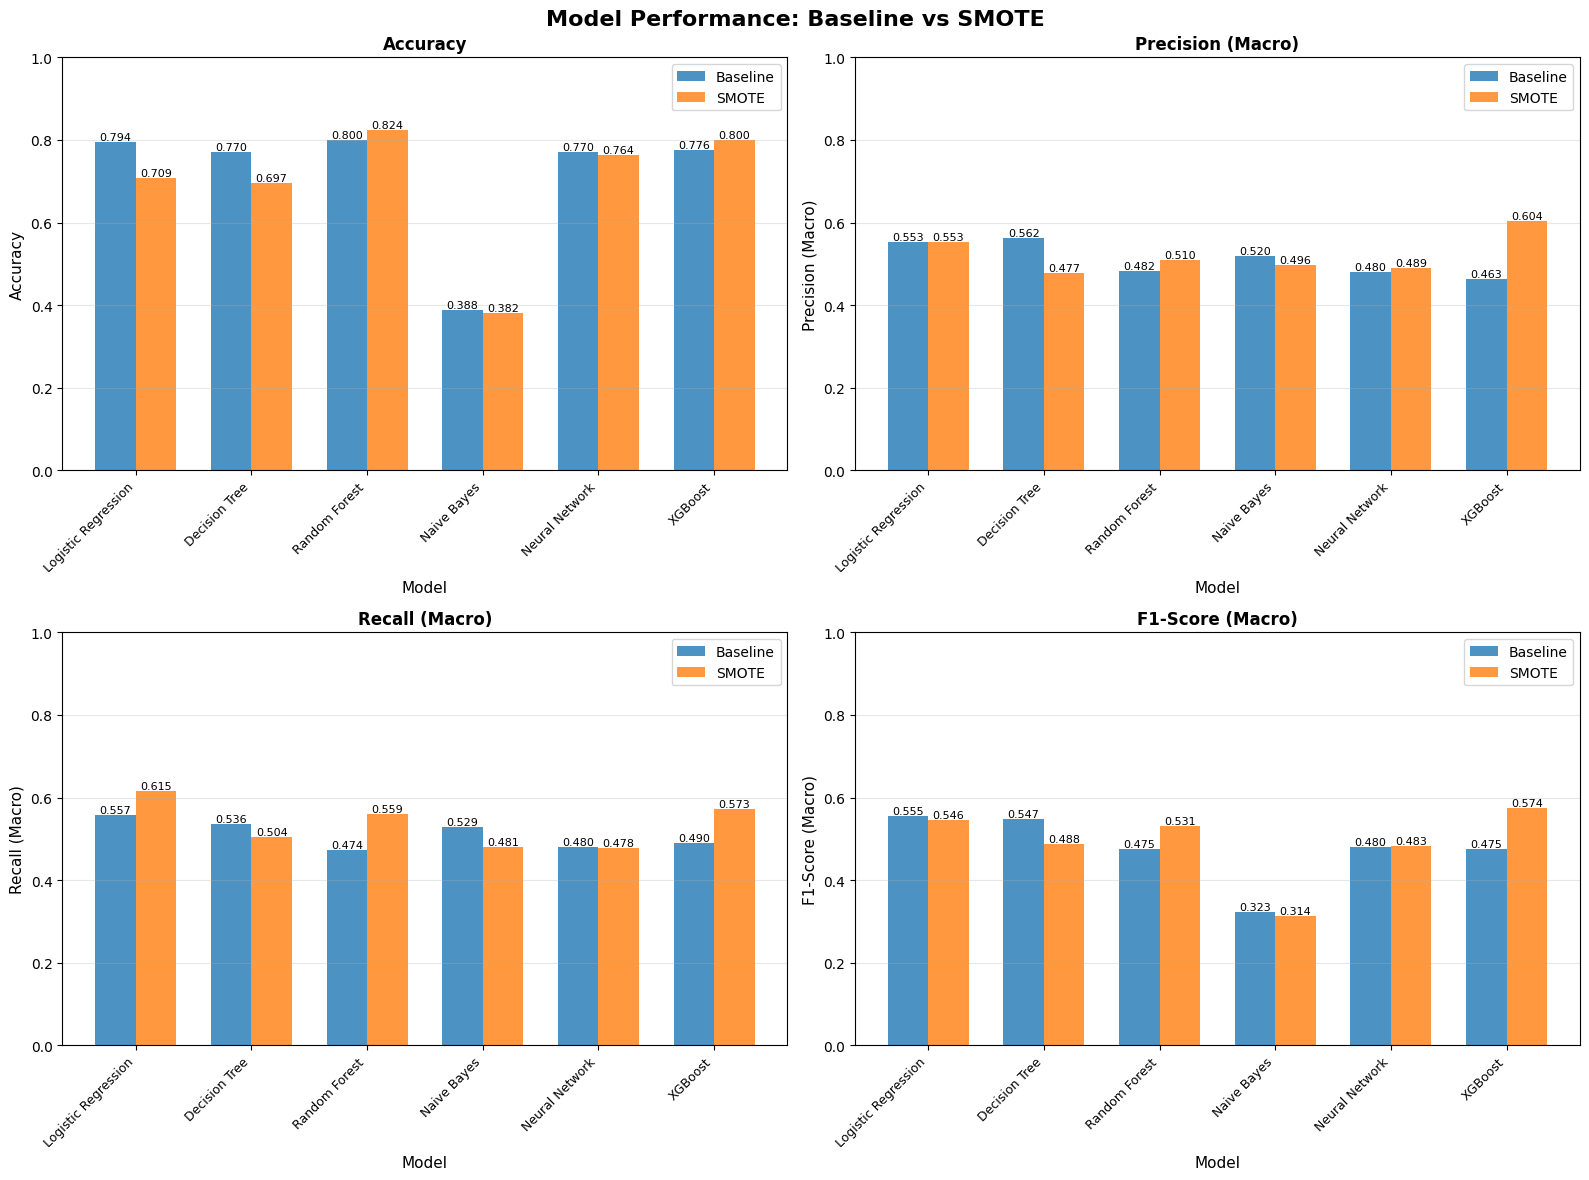

In [27]:
# Visualize comparison 
metrics = ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, metric in enumerate(metrics):
    metric_data = comparison_df[['Model', 'Method', metric]].copy()
    
    x = np.arange(len(models))
    width = 0.35
    
    baseline_values = metric_data[metric_data['Method'] == 'Baseline'][metric].values
    smote_values = metric_data[metric_data['Method'] == 'SMOTE'][metric].values
    
    bars1 = axes[idx].bar(x - width/2, baseline_values, width, label='Baseline', alpha=0.8, color='#1f77b4')
    bars2 = axes[idx].bar(x + width/2, smote_values, width, label='SMOTE', alpha=0.8, color='#ff7f0e')
    
    for bar in bars1:
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                      f'{height:.3f}', ha='center', va='bottom', fontsize=8)
    
    for bar in bars2:
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                      f'{height:.3f}', ha='center', va='bottom', fontsize=8)
    
    axes[idx].set_xlabel('Model', fontsize=11)
    axes[idx].set_ylabel(metric, fontsize=11)
    axes[idx].set_title(metric, fontsize=12, fontweight='bold')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(models.keys(), rotation=45, ha='right', fontsize=9)
    axes[idx].set_ylim([0, 1.0])
    axes[idx].legend(fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Model Performance: Baseline vs SMOTE', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
print("Detailed Classification Reports (Baseline Models)")

for name, results in baseline_results.items():
    print(f"\n{name}:")
    print(classification_report(y_test, results['predictions'], 
                                target_names=labelencoder.classes_,
                                zero_division=0))

Detailed Classification Reports (Baseline Models)

Logistic Regression:
              precision    recall  f1-score   support

          EC       0.12      0.14      0.13         7
         UEC       0.88      0.87      0.87       123
    USC/UPSC       0.66      0.66      0.66        35

    accuracy                           0.79       165
   macro avg       0.55      0.56      0.55       165
weighted avg       0.80      0.79      0.80       165


Decision Tree:
              precision    recall  f1-score   support

          EC       0.33      0.29      0.31         7
         UEC       0.85      0.89      0.87       123
    USC/UPSC       0.50      0.43      0.46        35

    accuracy                           0.77       165
   macro avg       0.56      0.54      0.55       165
weighted avg       0.76      0.77      0.76       165


Random Forest:
              precision    recall  f1-score   support

          EC       0.00      0.00      0.00         7
         UEC       0.84  

In [29]:
print("Detailed Classification Reports (SMOTE Models)")

for name, results in smote_results.items():
    print(f"\n{name}:")
    print(classification_report(y_test, results['predictions'], 
                                target_names=labelencoder.classes_,
                                zero_division=0))

Detailed Classification Reports (SMOTE Models)

Logistic Regression:
              precision    recall  f1-score   support

          EC       0.10      0.43      0.16         7
         UEC       0.93      0.73      0.82       123
    USC/UPSC       0.63      0.69      0.66        35

    accuracy                           0.71       165
   macro avg       0.55      0.62      0.55       165
weighted avg       0.83      0.71      0.76       165


Decision Tree:
              precision    recall  f1-score   support

          EC       0.20      0.29      0.24         7
         UEC       0.84      0.80      0.82       123
    USC/UPSC       0.39      0.43      0.41        35

    accuracy                           0.70       165
   macro avg       0.48      0.50      0.49       165
weighted avg       0.72      0.70      0.71       165


Random Forest:
              precision    recall  f1-score   support

          EC       0.00      0.00      0.00         7
         UEC       0.91     

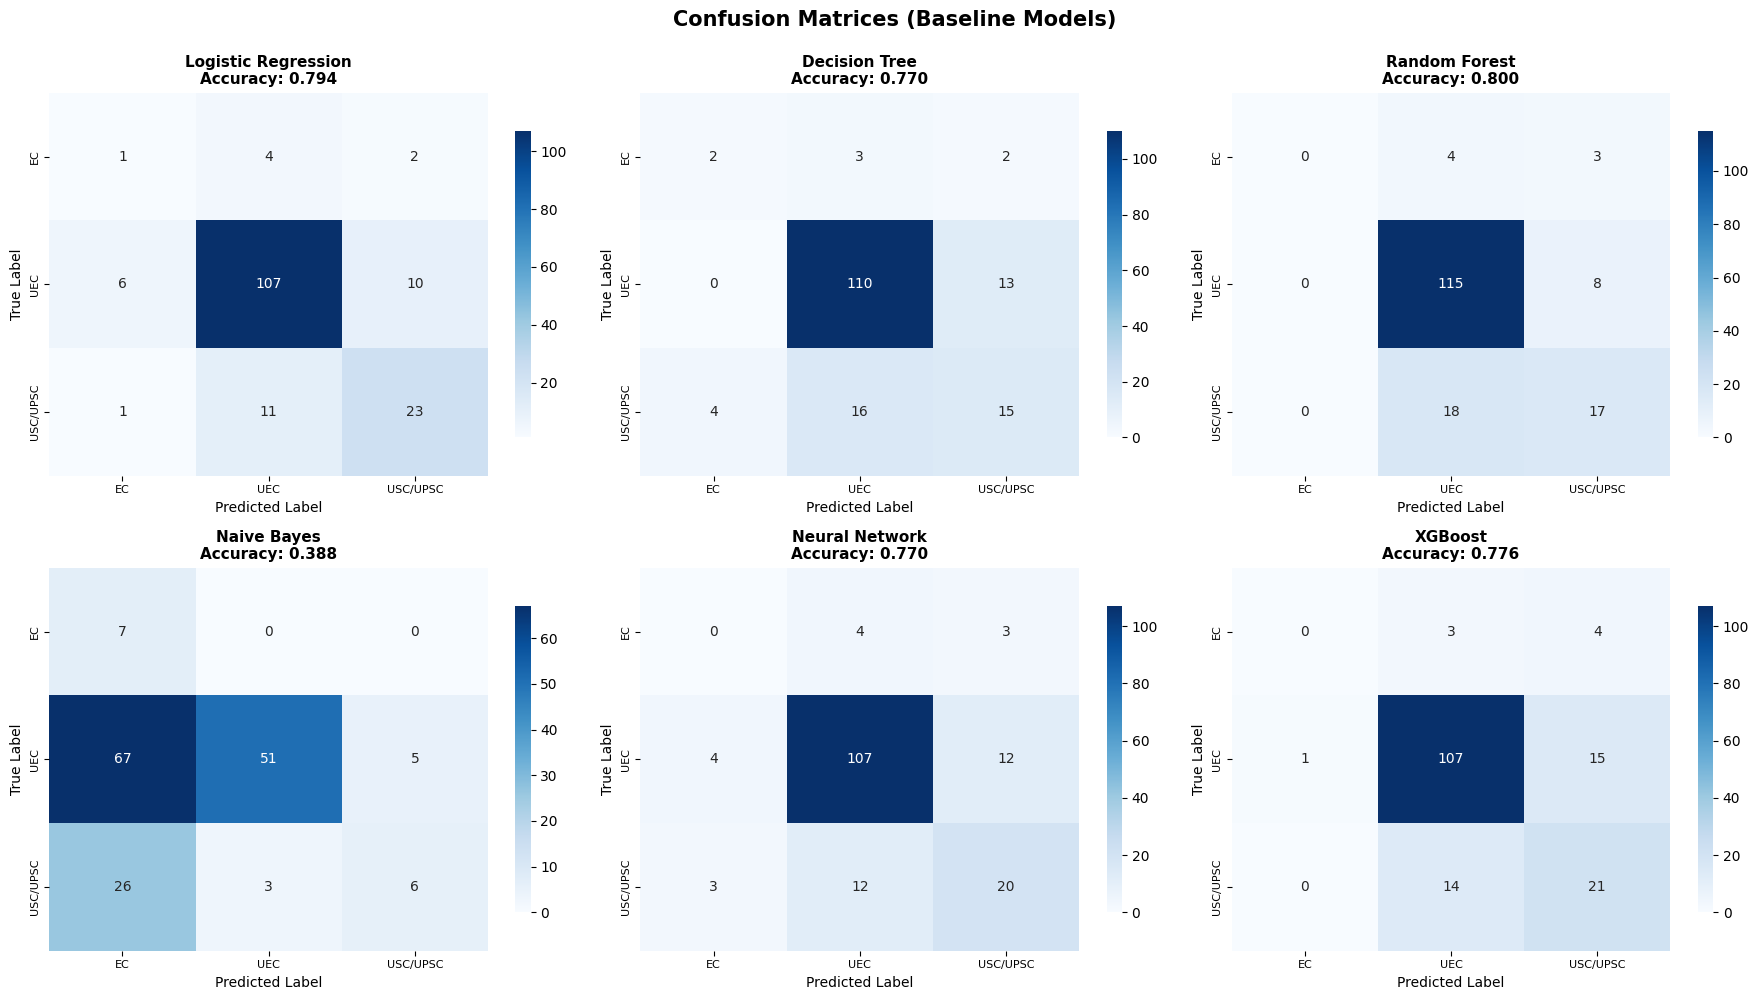

In [ ]:
n_models = len(baseline_results)
n_cols_cm = 3
n_rows_cm = (n_models + n_cols_cm - 1) // n_cols_cm

fig, axes = plt.subplots(n_rows_cm, n_cols_cm, figsize=(18, n_rows_cm * 5))
axes = axes.flatten()

wrapped_class_names = [textwrap.fill(name, 20) for name in labelencoder.classes_]

for idx, (name, results) in enumerate(baseline_results.items()):
    cm = confusion_matrix(y_test, results['predictions'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=wrapped_class_names, 
                yticklabels=wrapped_class_names,
                cbar_kws={'shrink': 0.8})
    axes[idx].set_title(f'{name}\nAccuracy: {results["accuracy"]:.3f}', 
                       fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('True Label', fontsize=10)
    axes[idx].set_xlabel('Predicted Label', fontsize=10)
    axes[idx].tick_params(axis='both', labelsize=8)
    

plt.suptitle('Confusion Matrices (Baseline Models)', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

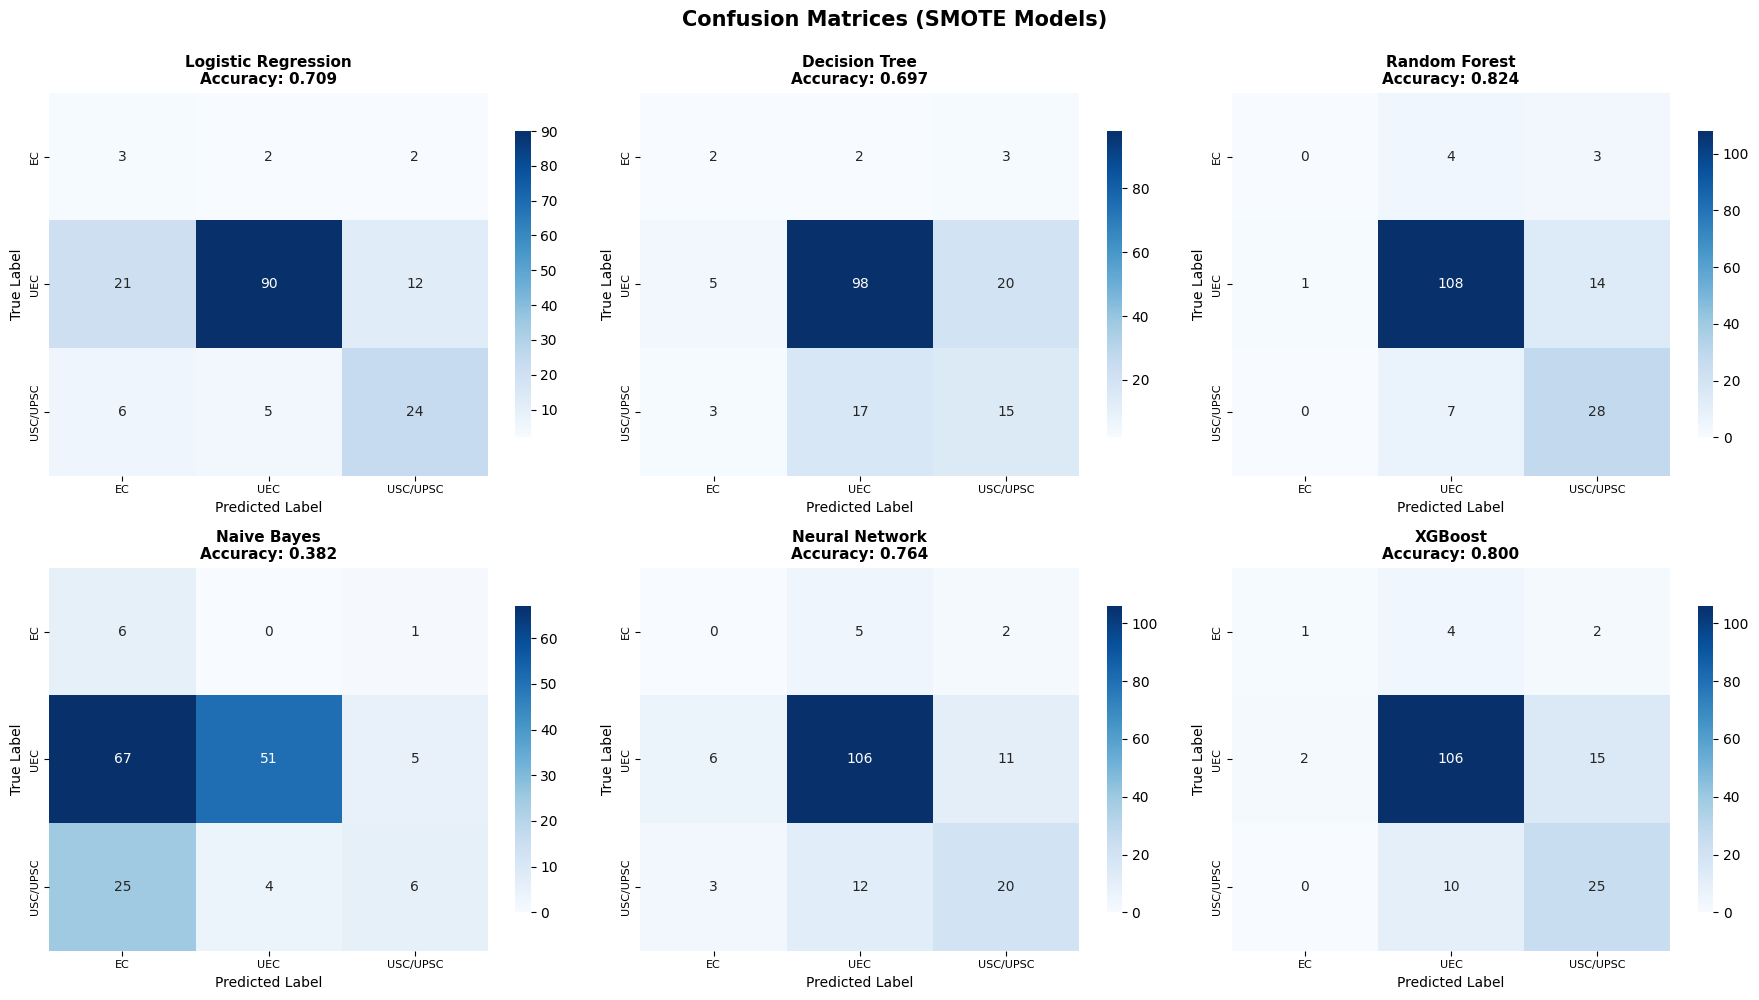

In [31]:
n_models = len(smote_results)
n_cols_cm = 3
n_rows_cm = (n_models + n_cols_cm - 1) // n_cols_cm

fig, axes = plt.subplots(n_rows_cm, n_cols_cm, figsize=(18, n_rows_cm * 5))
axes = axes.flatten()

wrapped_class_names = [textwrap.fill(name, 20) for name in labelencoder.classes_]

for idx, (name, results) in enumerate(smote_results.items()):
    cm = confusion_matrix(y_test, results['predictions'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=wrapped_class_names, 
                yticklabels=wrapped_class_names,
                cbar_kws={'shrink': 0.8})
    axes[idx].set_title(f'{name}\nAccuracy: {results["accuracy"]:.3f}', 
                       fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('True Label', fontsize=10)
    axes[idx].set_xlabel('Predicted Label', fontsize=10)
    axes[idx].tick_params(axis='both', labelsize=8)
    

plt.suptitle('Confusion Matrices (SMOTE Models)', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### Hyperparameter tuning on baseline models

In [32]:
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs', 'liblinear'],
        'max_iter': [1000]
    },
    'Decision Tree': {
        'max_depth': [5, 10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'criterion': ['gini', 'entropy']
    },
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [10, 15, 20],
        'min_samples_split': [10, 20],
        'min_samples_leaf': [4, 8],
        'class_weight': ['balanced', 'balanced_subsample']
    },
    'Naive Bayes': {
        'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
    },
    'Neural Network': {
        'hidden_layer_sizes': [(50,), (100,), (100, 50), (100, 100)],
        'activation': ['relu', 'tanh'],
        'alpha': [0.0001, 0.001, 0.01],
        'learning_rate': ['constant', 'adaptive']
    },
    'XGBoost': {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.3],
        'subsample': [0.8, 1.0]
    }
}

print("Hyperparameter grids defined for all models")

Hyperparameter grids defined for all models


In [33]:

baseline_tuned_results = {}

print("Performing Hyperparameter Tuning (GridSearchCV) for Baseline Models (Without SMOTE)")

for model_name in models.keys():
    print(f"\nTuning {model_name} (Baseline)")

    if model_name == 'Logistic Regression':
        base_model = LogisticRegression(random_state=42)
    elif model_name == 'Decision Tree':
        base_model = DecisionTreeClassifier(random_state=42)
    elif model_name == 'Random Forest':
        base_model = RandomForestClassifier(random_state=42)
    elif model_name == 'Naive Bayes':
        base_model = GaussianNB()
    elif model_name == 'Neural Network':
        base_model = MLPClassifier(max_iter=500, random_state=42)
    elif model_name == 'XGBoost':
        base_model = XGBClassifier(eval_metric='mlogloss', random_state=42)

    # Grid Search with 5-fold cross-validation
    grid_search = GridSearchCV(
        base_model,
        param_grids[model_name],
        cv=5,
        scoring='f1_macro',  # Using macro F1 for imbalanced data
        n_jobs=-1,
        verbose=1
    )

    # Fit on BASELINE training data (without SMOTE)
    grid_search.fit(X_train_scaled, y_train)

    # Get best model
    best_model = grid_search.best_estimator_

    y_pred = best_model.predict(X_test_scaled)

    # Calculate metrics 
    accuracy = accuracy_score(y_test, y_pred)
    precision_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall_weighted = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)

    baseline_tuned_results[model_name] = {
        'model': best_model,
        'best_params': grid_search.best_params_,
        'best_cv_score': grid_search.best_score_,
        'accuracy': accuracy,
        'precision': precision_weighted,
        'recall': recall_weighted,
        'f1_score': f1_weighted,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'predictions': y_pred
    }

    print(f"  Best CV Score (F1-Macro): {grid_search.best_score_:.4f}")
    print(f"  Test Accuracy:            {accuracy:.4f}")
    print(f"  Test F1-Score (Macro):    {f1_macro:.4f}")
    print(f"  Test F1-Score (Weighted): {f1_weighted:.4f}")
    print(f"  Best Parameters: {grid_search.best_params_}")

print("\nBaseline hyperparameter tuning complete!")

print("\nSummary of Tuned Baseline Models Performance:")

baseline_tuned_summary = pd.DataFrame([{
    'Model': name,
    'Best CV Score': results['best_cv_score'],
    'Test Accuracy': results['accuracy'],
    'Test F1 (Macro)': results['f1_macro'],
    'Test F1 (Weighted)': results['f1_score']
} for name, results in baseline_tuned_results.items()])

baseline_tuned_summary

Performing Hyperparameter Tuning (GridSearchCV) for Baseline Models (Without SMOTE)

Tuning Logistic Regression (Baseline)
Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\aswin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


  Best CV Score (F1-Macro): 0.5175
  Test Accuracy:            0.7879
  Test F1-Score (Macro):    0.5003
  Test F1-Score (Weighted): 0.7806
  Best Parameters: {'C': 0.01, 'max_iter': 1000, 'solver': 'liblinear'}

Tuning Decision Tree (Baseline)
Fitting 5 folds for each of 90 candidates, totalling 450 fits
  Best CV Score (F1-Macro): 0.5312
  Test Accuracy:            0.8121
  Test F1-Score (Macro):    0.4978
  Test F1-Score (Weighted): 0.7932
  Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}

Tuning Random Forest (Baseline)
Fitting 5 folds for each of 48 candidates, totalling 240 fits
  Best CV Score (F1-Macro): 0.5831
  Test Accuracy:            0.7758
  Test F1-Score (Macro):    0.4982
  Test F1-Score (Weighted): 0.7742
  Best Parameters: {'class_weight': 'balanced_subsample', 'max_depth': 10, 'min_samples_leaf': 8, 'min_samples_split': 10, 'n_estimators': 200}

Tuning Naive Bayes (Baseline)
Fitting 5 folds for each of 4 candid

,Model,Best CV Score,Test Accuracy,Test F1 (Macro),Test F1 (Weighted)
0,Logistic Regression,0.517487,0.787879,0.500271,0.780576
1,Decision Tree,0.531174,0.812121,0.497760,0.793173
2,Random Forest,0.583113,0.775758,0.498168,0.774159
3,Naive Bayes,0.311959,0.387879,0.322661,0.490471
4,Neural Network,0.495273,0.763636,0.472448,0.760269
5,XGBoost,0.523976,0.812121,0.506046,0.795629


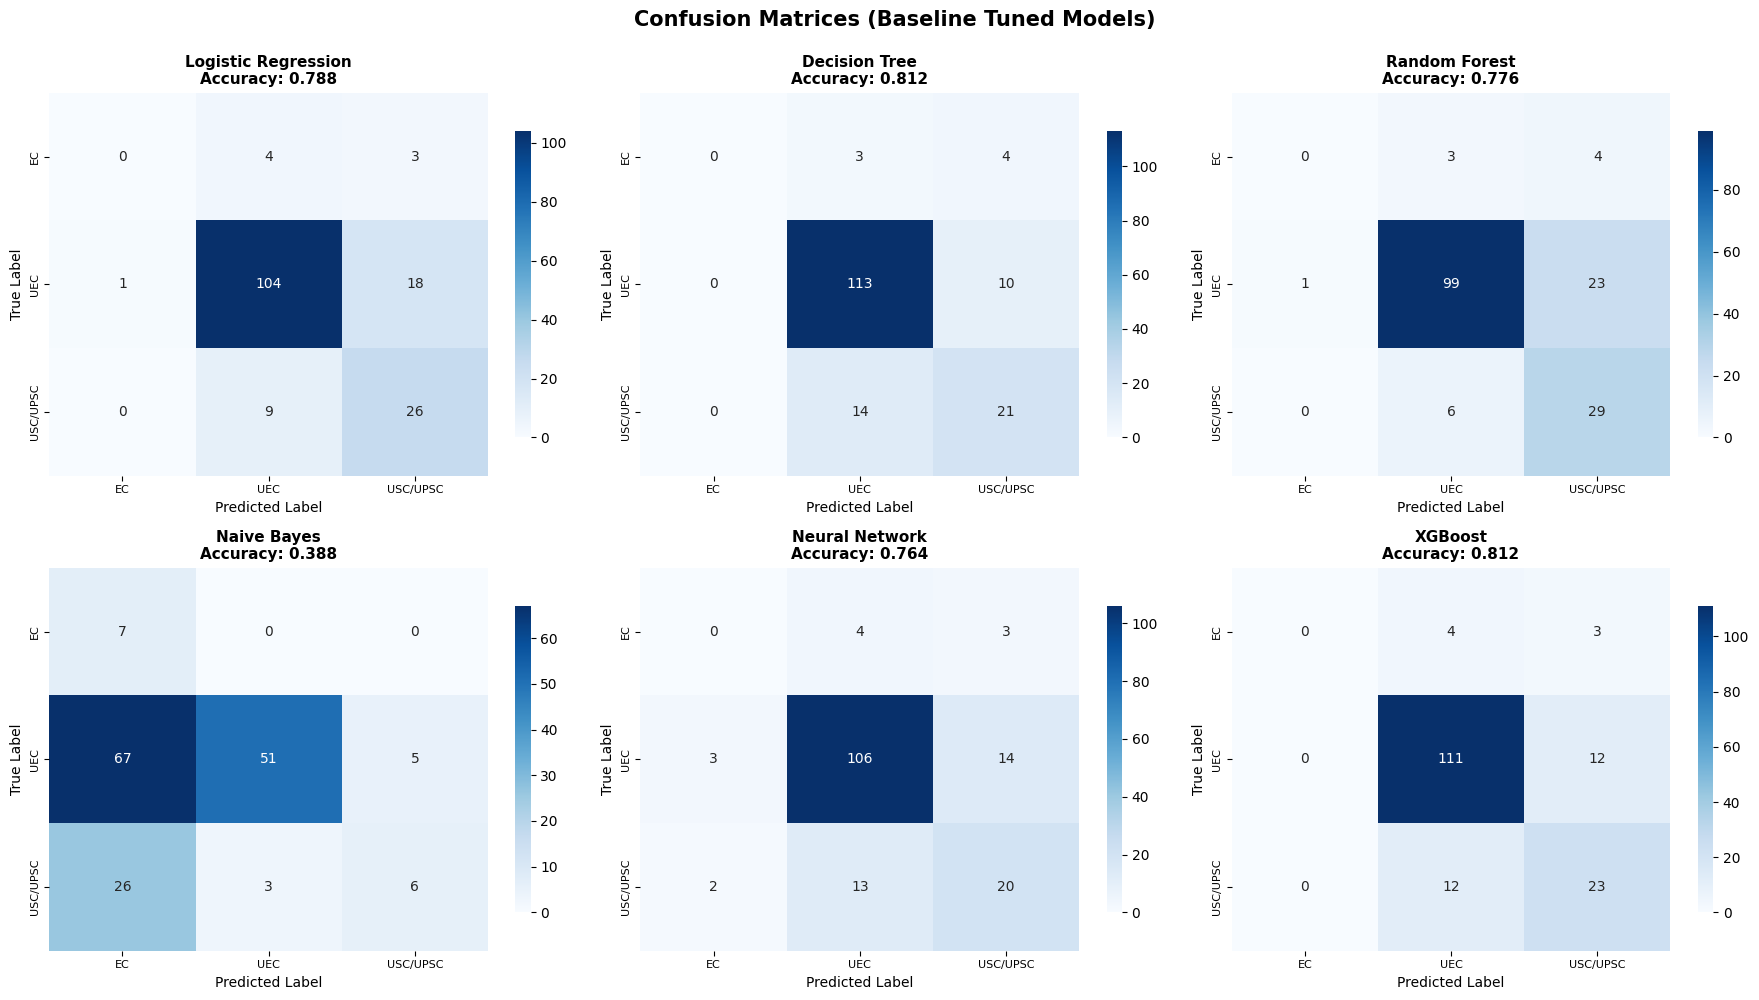

In [34]:
n_models = len(baseline_tuned_results)
n_cols_cm = 3
n_rows_cm = (n_models + n_cols_cm - 1) // n_cols_cm

fig, axes = plt.subplots(n_rows_cm, n_cols_cm, figsize=(18, n_rows_cm * 5))
axes = axes.flatten()

wrapped_class_names = [textwrap.fill(name, 20) for name in labelencoder.classes_]

for idx, (name, results) in enumerate(baseline_tuned_results.items()):
    cm = confusion_matrix(y_test, results['predictions'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=wrapped_class_names, 
                yticklabels=wrapped_class_names,
                cbar_kws={'shrink': 0.8})
    axes[idx].set_title(f'{name}\nAccuracy: {results["accuracy"]:.3f}', 
                       fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('True Label', fontsize=10)
    axes[idx].set_xlabel('Predicted Label', fontsize=10)
    axes[idx].tick_params(axis='both', labelsize=8)

plt.suptitle('Confusion Matrices (Baseline Tuned Models)', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [35]:
# Comprehensive comparison: Baseline vs Baseline Tuned vs SMOTE vs SMOTE Tuned
comprehensive_comparison = []

for name in models.keys():
    # Baseline (no tuning, no SMOTE)
    comprehensive_comparison.append({
        'Model': name,
        'Method': 'Baseline',
        'Best CV Score': '-',
        'Test Accuracy': baseline_results[name]['accuracy'],
        'Test F1 (Macro)': baseline_results[name]['f1_macro'],
        'Test F1 (Weighted)': baseline_results[name]['f1_score']
    })
    
    # Baseline Tuned (tuning, no SMOTE)
    comprehensive_comparison.append({
        'Model': name,
        'Method': 'Baseline Tuned',
        'Best CV Score': baseline_tuned_results[name]['best_cv_score'],
        'Test Accuracy': baseline_tuned_results[name]['accuracy'],
        'Test F1 (Macro)': baseline_tuned_results[name]['f1_macro'],
        'Test F1 (Weighted)': baseline_tuned_results[name]['f1_score']
    })
    
    # SMOTE (no tuning, with SMOTE)
    comprehensive_comparison.append({
        'Model': name,
        'Method': 'SMOTE',
        'Best CV Score': '-',
        'Test Accuracy': smote_results[name]['accuracy'],
        'Test F1 (Macro)': smote_results[name]['f1_macro'],
        'Test F1 (Weighted)': smote_results[name]['f1_score']
    })
    

comprehensive_df = pd.DataFrame(comprehensive_comparison)

print("Comprehensive Model Performance Comparison")
comprehensive_df

Comprehensive Model Performance Comparison


,Model,Method,Best CV Score,Test Accuracy,Test F1 (Macro),Test F1 (Weighted)
0,Logistic Regression,Baseline,-,0.793939,0.554649,0.796182
1,Logistic Regression,Baseline Tuned,0.517487,0.787879,0.500271,0.780576
2,Logistic Regression,SMOTE,-,0.709091,0.545959,0.756274
3,Decision Tree,Baseline,-,0.769697,0.547416,0.761749
4,Decision Tree,Baseline Tuned,0.531174,0.812121,0.497760,0.793173
5,Decision Tree,SMOTE,-,0.696970,0.487640,0.705943
6,Random Forest,Baseline,-,0.800000,0.474766,0.773919
7,Random Forest,Baseline Tuned,0.583113,0.775758,0.498168,0.774159
8,Random Forest,SMOTE,-,0.824242,0.530854,0.813849
9,Naive Bayes,Baseline,-,0.387879,0.322661,0.490471


### Feature Selection

In [36]:
# Try different numbers of features
n_features_options = [10, 15, 20, 25, 30]
dt_rfe_results = {}

for n_features in n_features_options:
    print(f"\nTesting with {n_features} features")
    
    dt_selector = RFE(
        estimator=DecisionTreeClassifier(random_state=42),
        n_features_to_select=n_features,
        step=1
    )
    
    dt_selector.fit(X_train_scaled, y_train)
    
    selected_features = X_encoded.columns[dt_selector.support_].tolist()
    
    X_train_rfe = dt_selector.transform(X_train_scaled)
    X_test_rfe = dt_selector.transform(X_test_scaled)
    
    dt_model = DecisionTreeClassifier(random_state=42)
    dt_model.fit(X_train_rfe, y_train)
    
    y_pred = dt_model.predict(X_test_rfe)
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    dt_rfe_results[n_features] = {
        'selector': dt_selector,
        'model': dt_model,
        'selected_features': selected_features,
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'predictions': y_pred
    }
    
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1-Score (Macro): {f1_macro:.4f}")
    print(f"  F1-Score (Weighted): {f1_weighted:.4f}")
    print(f"  Number of features selected: {len(selected_features)}")


Testing with 10 features
  Accuracy: 0.7273
  F1-Score (Macro): 0.4635
  F1-Score (Weighted): 0.7193
  Number of features selected: 10

Testing with 15 features
  Accuracy: 0.7152
  F1-Score (Macro): 0.4039
  F1-Score (Weighted): 0.7093
  Number of features selected: 15

Testing with 20 features
  Accuracy: 0.7273
  F1-Score (Macro): 0.4608
  F1-Score (Weighted): 0.7231
  Number of features selected: 20

Testing with 25 features
  Accuracy: 0.7636
  F1-Score (Macro): 0.5448
  F1-Score (Weighted): 0.7558
  Number of features selected: 25

Testing with 30 features
  Accuracy: 0.7273
  F1-Score (Macro): 0.4536
  F1-Score (Weighted): 0.7208
  Number of features selected: 30


In [37]:

best_dt_n_features = max(dt_rfe_results.keys(), key=lambda k: dt_rfe_results[k]['f1_macro'])
print(f"\n{'='*80}")
print(f"Best Decision Tree RFE: {best_dt_n_features} features")
print(f"Best F1-Score (Macro): {dt_rfe_results[best_dt_n_features]['f1_macro']:.4f}")
print(f"Best Accuracy: {dt_rfe_results[best_dt_n_features]['accuracy']:.4f}")
print(f"\nSelected Features ({best_dt_n_features}):")
for i, feat in enumerate(dt_rfe_results[best_dt_n_features]['selected_features'], 1):
    print(f"  {i}. {feat}")


Best Decision Tree RFE: 25 features
Best F1-Score (Macro): 0.5448
Best Accuracy: 0.7636

Selected Features (25):
  1. Diagnosis Age
  2. Fraction Genome Altered
  3. Patient Height
  4. Mutation Count
  5. Tumor invasion percent
  6. Patient Weight
  7. JCCC Stage_Stage IA
  8. JCCC Stage_Stage IC
  9. JCCC Stage_Stage II
  10. JCCC Stage_Stage IV
  11. JCCC Stage_Stage IVB
  12. Neoplasm Histologic Grade_G2
  13. Neoplasm Histologic Grade_G3
  14. Neoplasm Histologic Grade_High Grade
  15. Hypertension diagnosis_YES
  16. Peritoneal washing_negative
  17. Peritoneal washing_positive
  18. Pregncies full term count_1
  19. Pregncies full term count_2
  20. Pregncies full term count_3
  21. Race Category_BLACK OR AFRICAN AMERICAN
  22. Race Category_TIVE HAWAIIAN OR OTHER PACIFIC ISLANDER
  23. Race Category_WHITE
  24. Surgical Margin Resection Status_R1
  25. Surgical Margin Resection Status_RX


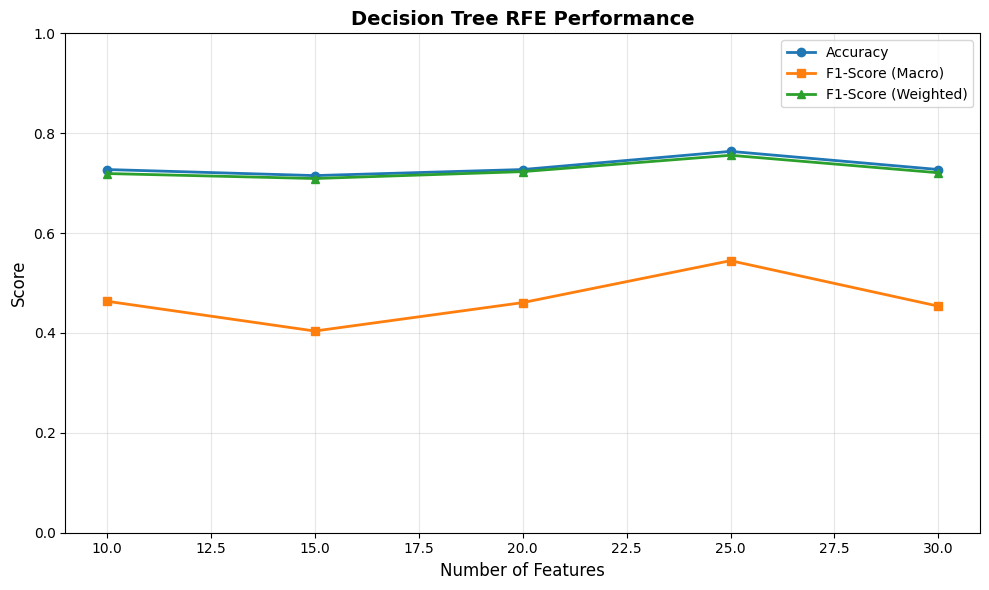

In [38]:
# Visualize RFE results
plt.figure(figsize=(10, 6))

# Plot for Decision Tree
plt.plot(n_features_options, [dt_rfe_results[n]['accuracy'] for n in n_features_options], 
         marker='o', label='Accuracy', linewidth=2)
plt.plot(n_features_options, [dt_rfe_results[n]['f1_macro'] for n in n_features_options], 
         marker='s', label='F1-Score (Macro)', linewidth=2)
plt.plot(n_features_options, [dt_rfe_results[n]['f1_weighted'] for n in n_features_options], 
         marker='^', label='F1-Score (Weighted)', linewidth=2)
plt.xlabel('Number of Features', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Decision Tree RFE Performance', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.ylim([0, 1.0])

plt.tight_layout()
plt.show()

In [39]:
# Retrain ALL models with the best features from Random Forest RFE

print(f"Retraining All Models with Best Random Forest RFE Features ({best_dt_n_features} features)")

best_dt_selector = dt_rfe_results[best_dt_n_features]['selector']
X_train_dt_rfe = best_dt_selector.transform(X_train_scaled)
X_test_dt_rfe = best_dt_selector.transform(X_test_scaled)

# Retrain all models
dt_rfe_all_models = {}

for name, model in models.items():
    print(f"\nTraining {name} with DT-RFE features")
    
    if name == 'Logistic Regression':
        fresh_model = LogisticRegression(max_iter=1000, random_state=42)
    elif name == 'Decision Tree':
        fresh_model = DecisionTreeClassifier(random_state=42)
    elif name == 'Random Forest':
        fresh_model = RandomForestClassifier(n_estimators=100, random_state=42)
    elif name == 'Naive Bayes':
        fresh_model = GaussianNB()
    elif name == 'Neural Network':
        fresh_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
    elif name == 'XGBoost':
        fresh_model = XGBClassifier(eval_metric='mlogloss', random_state=42)
    
    # Train
    fresh_model.fit(X_train_dt_rfe, y_train)
    
    # Evaluate
    y_pred = fresh_model.predict(X_test_dt_rfe)
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    
    dt_rfe_all_models[name] = {
        'model': fresh_model,
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'predictions': y_pred
    }
    
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1-Score (Macro): {f1_macro:.4f}")
    print(f"  F1-Score (Weighted): {f1_weighted:.4f}")

print("\nAll models retrained with RF-RFE features!")

Retraining All Models with Best Random Forest RFE Features (25 features)

Training Logistic Regression with DT-RFE features
  Accuracy: 0.8364
  F1-Score (Macro): 0.5241
  F1-Score (Weighted): 0.8164

Training Decision Tree with DT-RFE features
  Accuracy: 0.7636
  F1-Score (Macro): 0.5448
  F1-Score (Weighted): 0.7558

Training Random Forest with DT-RFE features
  Accuracy: 0.8303
  F1-Score (Macro): 0.5130
  F1-Score (Weighted): 0.8079

Training Naive Bayes with DT-RFE features
  Accuracy: 0.2727
  F1-Score (Macro): 0.2633
  F1-Score (Weighted): 0.3745

Training Neural Network with DT-RFE features
  Accuracy: 0.7939
  F1-Score (Macro): 0.4956
  F1-Score (Weighted): 0.7856

Training XGBoost with DT-RFE features
  Accuracy: 0.7636
  F1-Score (Macro): 0.4600
  F1-Score (Weighted): 0.7511

All models retrained with RF-RFE features!


c:\Users\aswin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


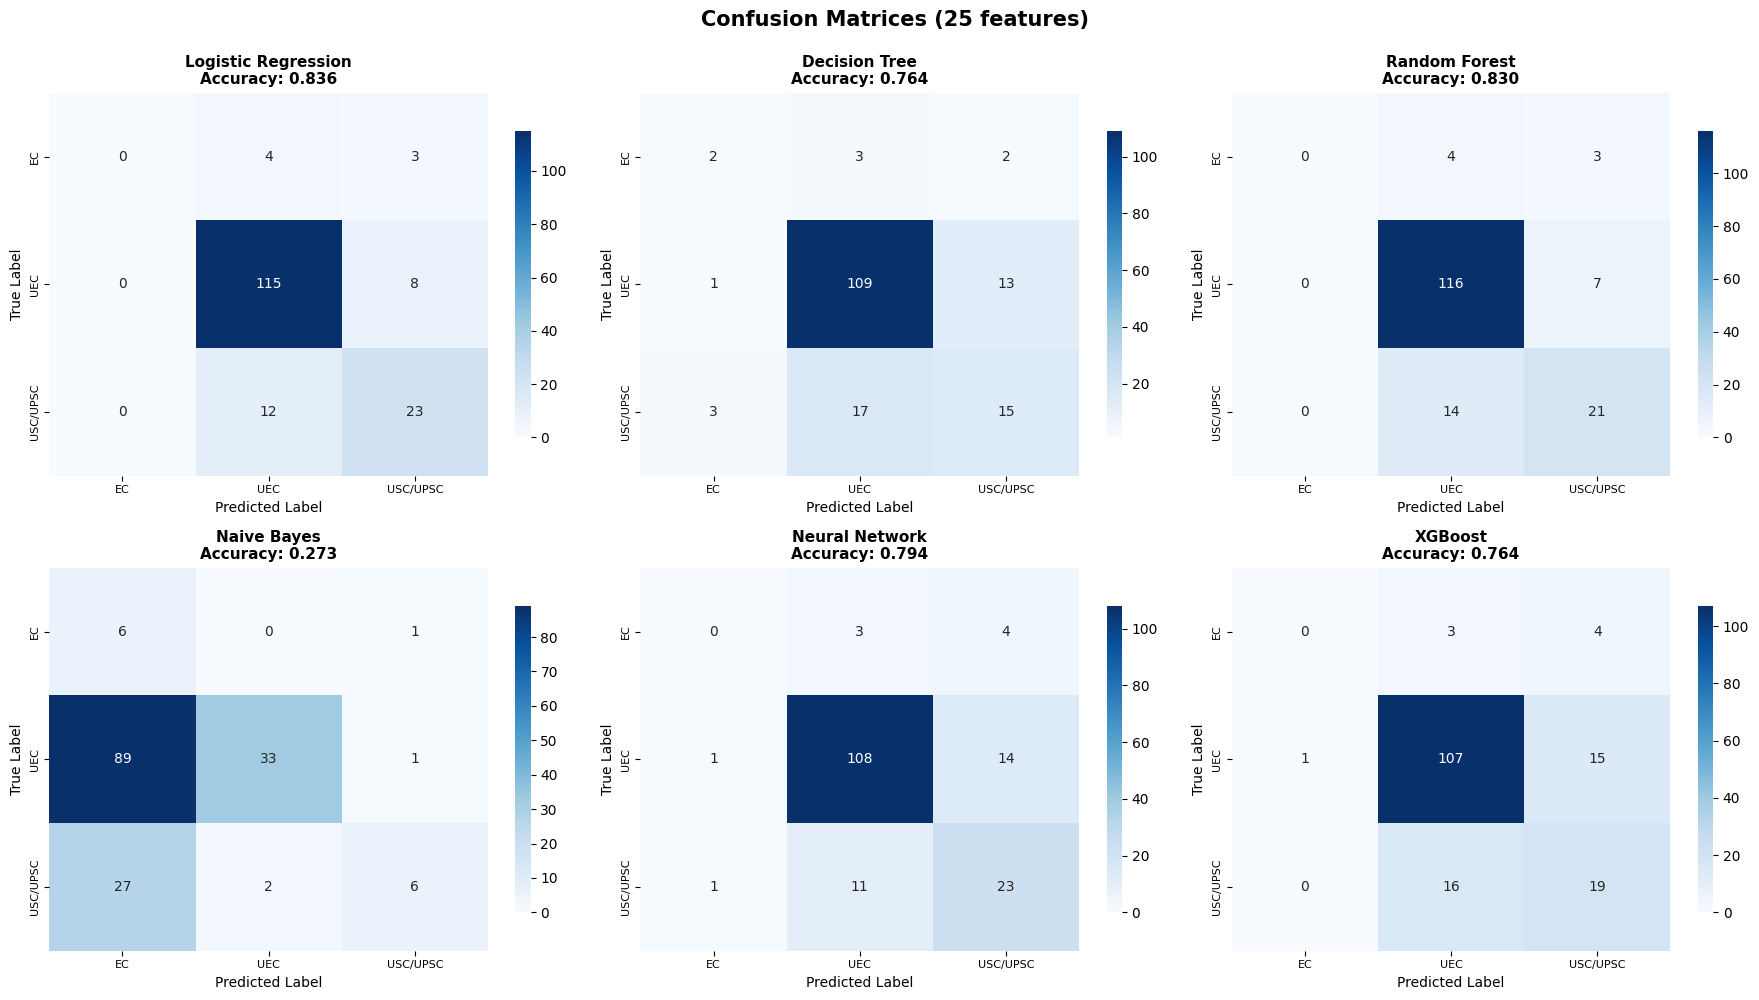

In [40]:
n_models = len(dt_rfe_all_models)
n_cols_cm = 3
n_rows_cm = (n_models + n_cols_cm - 1) // n_cols_cm

fig, axes = plt.subplots(n_rows_cm, n_cols_cm, figsize=(18, n_rows_cm * 5))
axes = axes.flatten()

# Wrap class names for better readability
wrapped_class_names = [textwrap.fill(name, 20) for name in labelencoder.classes_]

for idx, (name, results) in enumerate(dt_rfe_all_models.items()):
    cm = confusion_matrix(y_test, results['predictions'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=wrapped_class_names, 
                yticklabels=wrapped_class_names,
                cbar_kws={'shrink': 0.8})
    axes[idx].set_title(f'{name}\nAccuracy: {results["accuracy"]:.3f}', 
                       fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('True Label', fontsize=10)
    axes[idx].set_xlabel('Predicted Label', fontsize=10)
    axes[idx].tick_params(axis='both', labelsize=8)
    

plt.suptitle('Confusion Matrices (25 features)', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [41]:
# Comprehensive comparison including RFE results
final_comparison = []

for name in models.keys():
    # Baseline
    final_comparison.append({
        'Model': name,
        'Feature Selection': 'None (All Features)',
        'Accuracy': baseline_results[name]['accuracy'],
        'F1 (Macro)': baseline_results[name]['f1_macro'],
        'F1 (Weighted)': baseline_results[name]['f1_score']
    })
    
    # RF-RFE
    final_comparison.append({
        'Model': name,
        'Feature Selection': f'RF-RFE ({best_dt_n_features} features)',
        'Accuracy': dt_rfe_all_models[name]['accuracy'],
        'F1 (Macro)': dt_rfe_all_models[name]['f1_macro'],
        'F1 (Weighted)': dt_rfe_all_models[name]['f1_weighted']
    })
    

final_comparison_df = pd.DataFrame(final_comparison)

print("Final Comparison: Baseline vs RFE Feature Selection")
final_comparison_df

Final Comparison: Baseline vs RFE Feature Selection


,Model,Feature Selection,Accuracy,F1 (Macro),F1 (Weighted)
0,Logistic Regression,None (All Features),0.793939,0.554649,0.796182
1,Logistic Regression,RF-RFE (25 features),0.836364,0.524059,0.816432
2,Decision Tree,None (All Features),0.769697,0.547416,0.761749
3,Decision Tree,RF-RFE (25 features),0.763636,0.544770,0.755833
4,Random Forest,None (All Features),0.800000,0.474766,0.773919
5,Random Forest,RF-RFE (25 features),0.830303,0.513029,0.807926
6,Naive Bayes,None (All Features),0.387879,0.322661,0.490471
7,Naive Bayes,RF-RFE (25 features),0.272727,0.263272,0.374535
8,Neural Network,None (All Features),0.769697,0.480449,0.769697
9,Neural Network,RF-RFE (25 features),0.793939,0.495632,0.785606
